# Network Flows — Detección de Anomalías en Red Industrial
## Marco teórico: Iturbe (2026) — *Seguridad guiada por datos*

---

## 0. Marco conceptual

### 0.1 Qué es una anomalía

> *"Los ADSs intentan detectar actividad anormal modelando la normalidad existente y detectando patrones que se desvían de ésta. **No buscan patrones de ataques conocidos, sino situaciones anormales o diferentes.**"* — Iturbe (2026)

Una anomalía es un flujo que se aleja del modelo de normalidad aprendido sin etiquetas. No es necesariamente un ataque: puede ser mantenimiento, equipo nuevo o configuración inusual. Por eso los ADS sufren de falsos positivos (Iturbe, slide 32). La suposición básica:

> *"La actividad legítima y la intrusión se comportan de forma diferente."* (slide 28)

### 0.2 Decisiones técnicas que estructuran el pipeline

Cada decisión está respaldada por análisis empírico de outputs del propio dataset, no por suposiciones generales:

| Decisión | Justificación basada en outputs |
|---|---|
| IF sin `contamination`, umbral por percentil | Score range `[-0.64, -0.41]` estrecho y unimodal; umbral genérico -0.5 cae en el centro |
| Tres niveles de severidad (P0.1 / P5 / resto) | El gradiente máximo de la curva de scores está en P0.1% |
| **HDBSCAN** como clustering del subconjunto normal | El tráfico normal no tiene clusters esféricos: K-Means da K=2 con 61.5% en "Mixto / sin clasificar". Una partición basada en densidad refleja la forma real de los datos |
| **K-Means con K_min=3** en el subconjunto anómalo | K=2 produce 98.8% / 1.2% — distribución trivial sin valor SOC |
| `min_cluster_size` HDBSCAN escalado: **2000 normal, 200 anómalo** | Valores menores (p. ej. mcs=50) generan 167 y 2.649 clusters — fragmentación estadística sin interpretación operativa |
| Etiquetado basado en IAT y duración | Las features con mayor d de Cohen son temporales; las reglas de flags producirían 100% "sin clasificar" |
| **Cohen's d** en lugar de ratio de medianas | Las features binarias dan ratios explosivos (~153.677x) con esa métrica |

### 0.3 Arquitectura del pipeline

```
                  Datos preprocesados (log1p + StandardScaler)
                                  │
                                  ▼
                       ┌─── Isolation Forest ───┐
                       │   (sin contamination)  │
                       │     Score continuo     │
                       └────────────┬───────────┘
                                    │
              ┌─────────────────────┼─────────────────────┐
              ▼                     ▼                     ▼
        Crítico P0.1%        Anómalo P5            Normal (95%)
        (~3.500 flujos)    (~175.000 flujos)      (~3.4M flujos)
              │                     │                     │
              │                     ▼                     ▼
              │              K-Means + HDBSCAN       HDBSCAN
              │              (K_min=3, mcs=200)      (mcs=2000)
              │                     │                     │
              └─────────────────────┼─────────────────────┘
                                    ▼
                       Autoencoder (entrenado en normal)
                                    │
                                    ▼
                  Interpretación SOC con prioridades P1-P4
```

### 0.4 Tabla de responsabilidades

| Componente | Pregunta que responde | Algoritmo |
|---|---|---|
| Separador binario | ¿Es este flujo anómalo? | Isolation Forest |
| Severidad | ¿Cuán crítico es? | Percentil del score IF |
| Tipificador normal | ¿Qué tipo de tráfico legítimo es? | HDBSCAN |
| Tipificador anómalo | ¿Qué tipo de amenaza es? | K-Means con K_min=3 |
| Sub-grupos densos (anómalo) | ¿Hay sub-patrones específicos dentro del anómalo? | HDBSCAN |
| Detector fino | ¿Rompe correlaciones del normal? | Autoencoder |

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score,
                              calinski_harabasz_score,
                              davies_bouldin_score,
                              cohen_kappa_score)

import hdbscan

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Carga de datos limpios

Cargamos los Parquet del notebook de limpieza. Tres matrices: features para ML (`df_X`), metadatos para interpretación (`df_meta`) y etiquetas (`df_y`).

In [ ]:
from pathlib import Path

PARQUET_X    = 'Datos/Transformados/network_flows_X.parquet'
PARQUET_META = 'Datos/Transformados/network_flows_meta.parquet'
PARQUET_Y    = 'Datos/Transformados/network_flows_y.parquet'

df_X    = pl.read_parquet(PARQUET_X).to_pandas()
df_meta = pl.read_parquet(PARQUET_META).to_pandas()
df_y    = pl.read_parquet(PARQUET_Y).to_pandas()

print(f'Features (X):     {df_X.shape}')
print(f'Metadatos (meta): {df_meta.shape}')
print(f'Target (y):       {df_y.shape}')
print(f'Distribución de Label: {df_y["Label"].value_counts().to_dict()}')

Features (X):     (3577296, 94)
Metadatos (meta): (3577296, 6)
Target (y):       (3577296, 1)
Distribución de Label: {'BENIGN': 3577296}


## 2. Preprocesado para ML

### 2.1 Por qué `log1p` antes de escalar

Las features de red tienen distribuciones extremadamente sesgadas (`Flow.Bytes.s` varía de 0 a 10⁹). Con valores en bruto un único flujo de 1 GB/s domina los cálculos y aplasta las diferencias del rango normal. `log1p(x) = ln(1+x)` comprime la cola derecha y preserva el cero. Tras la transformación las distancias reflejan diferencias relativas, no absolutas.

### 2.2 Por qué `StandardScaler` después

Aún con log1p, las features tienen escalas distintas: duración en millones de μs, flags en 0/1, tasas en enteros pequeños. `StandardScaler` lleva cada feature a `mean=0, std=1`. Todas las dimensiones se vuelven comparables para distancias euclídeas y para las particiones de IF.

### 2.3 Shuffle global

Un solo shuffle reproducible con seed fija evita sesgo temporal: si los primeros minutos de captura contuvieran una ráfaga atípica, sin shuffle el subconjunto anómalo después de IF estaría sobrerrepresentado por ese evento.

In [3]:
# ── Filtrar features numéricas con varianza no nula ──────────────────────────
# Una columna constante no aporta información: no distingue clusters, no genera
# cortes informativos en IF, y rompe numéricamente algunas operaciones.

numeric_cols = df_X.select_dtypes(include=[np.number]).columns.tolist()
var_per_col  = df_X[numeric_cols].var()
feature_cols = var_per_col[var_per_col > 1e-10].index.tolist()

print(f'Total numéricas:          {len(numeric_cols)}')
print(f'Con varianza > 1e-10:     {len(feature_cols)}')
print(f'Eliminadas por var nula:  {len(numeric_cols) - len(feature_cols)}')

X_raw = df_X[feature_cols].copy()
X_raw = X_raw.replace([np.inf, -np.inf], np.nan).fillna(0)

# log1p solo a columnas sin negativos (logaritmo no está definido para x<0)
has_negatives = (X_raw.min() < 0)
log_safe_cols = X_raw.columns[~has_negatives].tolist()
non_log_cols  = X_raw.columns[has_negatives].tolist()

X_log = X_raw.copy()
X_log[log_safe_cols] = np.log1p(X_raw[log_safe_cols])

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

rng          = np.random.default_rng(42)
shuffled_idx = rng.permutation(X_scaled.shape[0])
X_shuffled   = X_scaled[shuffled_idx]
n_total      = X_scaled.shape[0]

# Identificamos columnas binarias para excluirlas del análisis Cohen's d
# (estas son indicadores categóricos: dst_is_*, proto_*, is_TCP, is_UDP, etc.)
binary_cols = [c for c in feature_cols
               if df_X[c].nunique() <= 2
               and set(df_X[c].dropna().unique()).issubset({0, 1, 0.0, 1.0, True, False})]

print(f'\nMatriz de entrenamiento: {X_scaled.shape}')
print(f'Features para el modelo: {len(feature_cols)}')
print(f'log1p aplicado a {len(log_safe_cols)} columnas')
print(f'Columnas con negativos (sin log1p): {non_log_cols[:5]}...')
print(f'Columnas binarias detectadas (se excluyen de Cohen\'s d): {len(binary_cols)}')
print(f'\nX_scaled — media: {X_scaled.mean():.6f}, std: {X_scaled.std():.6f}')

Total numéricas:          94
Con varianza > 1e-10:     89
Eliminadas por var nula:  5

Matriz de entrenamiento: (3577296, 89)
Features para el modelo: 89
log1p aplicado a 81 columnas
Columnas con negativos (sin log1p): ['Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'min_seg_size_forward', 'hour_cos', 'minute_sin']...
Columnas binarias detectadas (se excluyen de Cohen's d): 30

X_scaled — media: -0.000000, std: 1.000000


## 3. Isolation Forest como separador con tres niveles de severidad

### 3.1 Principio del algoritmo

IF construye un bosque de árboles de aislamiento. Cada árbol selecciona una feature al azar, un valor de corte al azar, y particiona recursivamente. **Idea clave**: las anomalías se aíslan en pocas particiones (raras y distintas), los normales necesitan muchas (densamente agrupados).

`score_samples(x)` retorna un valor proporcional a la profundidad media de aislamiento normalizada: **más negativo = más anómalo**.

### 3.2 Por qué IF como separador

| Criterio | K-Means | HDBSCAN | **IF** |
|---|---|---|---|
| Decisión binaria sin "no asignados" | sí | no (ruido=-1) | **sí** |
| No asume forma de clusters | no | sí | **sí** |
| Inmune a maldición de dimensionalidad | no | parcial | **sí** |
| Escala lineal en n | sí | sí (O(n log n)) | **sí O(n·trees)** |
| Score continuo para ajustar umbral | no | no | **sí** |

La última fila es decisiva: ajustamos el umbral post-entrenamiento usando percentiles del score sin reentrenar.

### 3.3 El problema empírico de `contamination='auto'`

Sklearn implementa `contamination='auto'` con el umbral del paper original (Liu et al. 2008): score = -0.5. **Lo que observamos al entrenar IF sin contamination en nuestros datos:**

```
Score range: [-0.6404, -0.4057]   ← rango estrecho (0.234 unidades)
Score media ± std: -0.4824 ± 0.0371
Umbral auto (-0.5)                ← cae en el centro → parte 70/30
```

Un rango tan estrecho y completamente negativo indica que la distribución de scores es **unimodal y continua**. IF no encuentra una frontera natural binaria. El 30% que resulta del umbral genérico es un artefacto, no la tasa real de anomalías.

### 3.4 Solución: tres niveles de severidad con base empírica

| Nivel | Criterio | Tamaño esperado | Acción SOC |
|---|---|---|---|
| **Crítico** | `if_score` < P0.1 | ~3.500 flujos | Revisar inmediato |
| **Anómalo** | P0.1 ≤ `if_score` < P5 | ~175.000 flujos | Triaje + clustering |
| **Normal** | `if_score` ≥ P5 | ~3.4M flujos | Monitorizar |

El nivel crítico está justificado **empíricamente** por el gradiente máximo de la curva de scores (siguiente celda); el nivel anómalo (P5) está justificado **operativamente** por la literatura sobre redes industriales (Goldstein & Uchida 2016; Iturbe 2026 slide 35).

Isolation Forest entrenado sobre 3,577,296 muestras
Score range: [-0.6404, -0.4057]
Score media:  -0.4824
Score std:    0.0371
Rango total: 0.2347 unidades
→ Distribución estrecha y unimodal — confirma necesidad de umbral manual


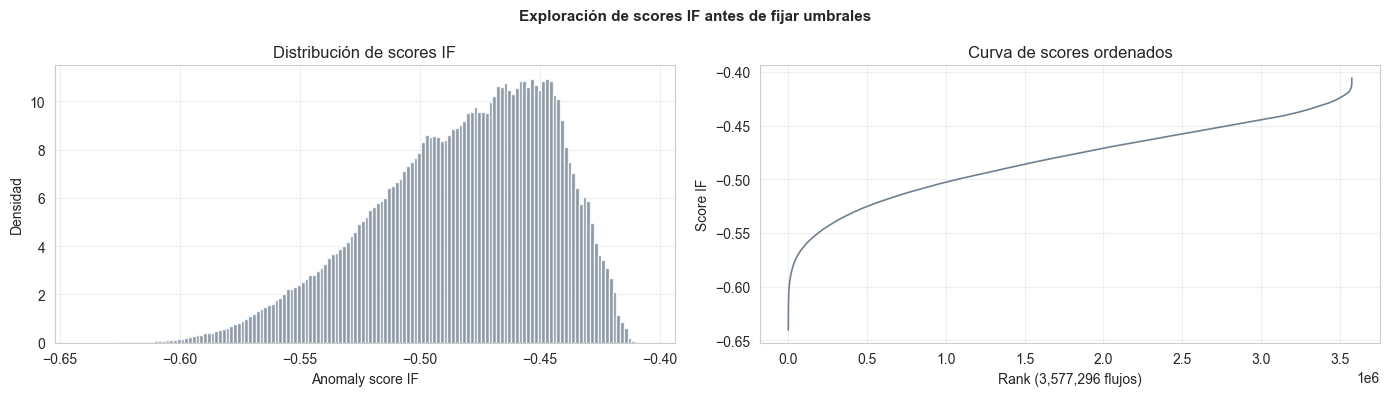

In [4]:
# ── Isolation Forest sin contamination ───────────────────────────────────────
# Entrenamos sobre todos los datos (IF es O(n·trees), ~14s para 3.5M).
# n_estimators=200 reduce la varianza del score → umbrales por percentil más estables.

iso = IsolationForest(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
)

iso.fit(X_scaled)
iso_score = iso.score_samples(X_scaled)
df_X['if_score'] = iso_score

print(f'Isolation Forest entrenado sobre {n_total:,} muestras')
print(f'Score range: [{iso_score.min():.4f}, {iso_score.max():.4f}]')
print(f'Score media:  {iso_score.mean():.4f}')
print(f'Score std:    {iso_score.std():.4f}')
print(f'Rango total: {iso_score.max() - iso_score.min():.4f} unidades')
print(f'→ Distribución estrecha y unimodal — confirma necesidad de umbral manual')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(iso_score, bins=150, color='slategray', alpha=0.8, density=True)
axes[0].set_xlabel('Anomaly score IF'); axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de scores IF')
axes[0].grid(True, alpha=0.3)

scores_sorted = np.sort(iso_score)
axes[1].plot(scores_sorted, color='slategray', linewidth=1.2)
axes[1].set_xlabel(f'Rank ({n_total:,} flujos)')
axes[1].set_ylabel('Score IF')
axes[1].set_title('Curva de scores ordenados')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Exploración de scores IF antes de fijar umbrales',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Calibración: análisis del gradiente

El gradiente numérico de la curva de scores ordenados indica dónde la pendiente cambia más bruscamente. Un pico en el gradiente revela un codo natural (separación clara entre normales y anómalos). Si la curva es continua, el gradiente es plano y cualquier umbral es operativo, no estadístico.


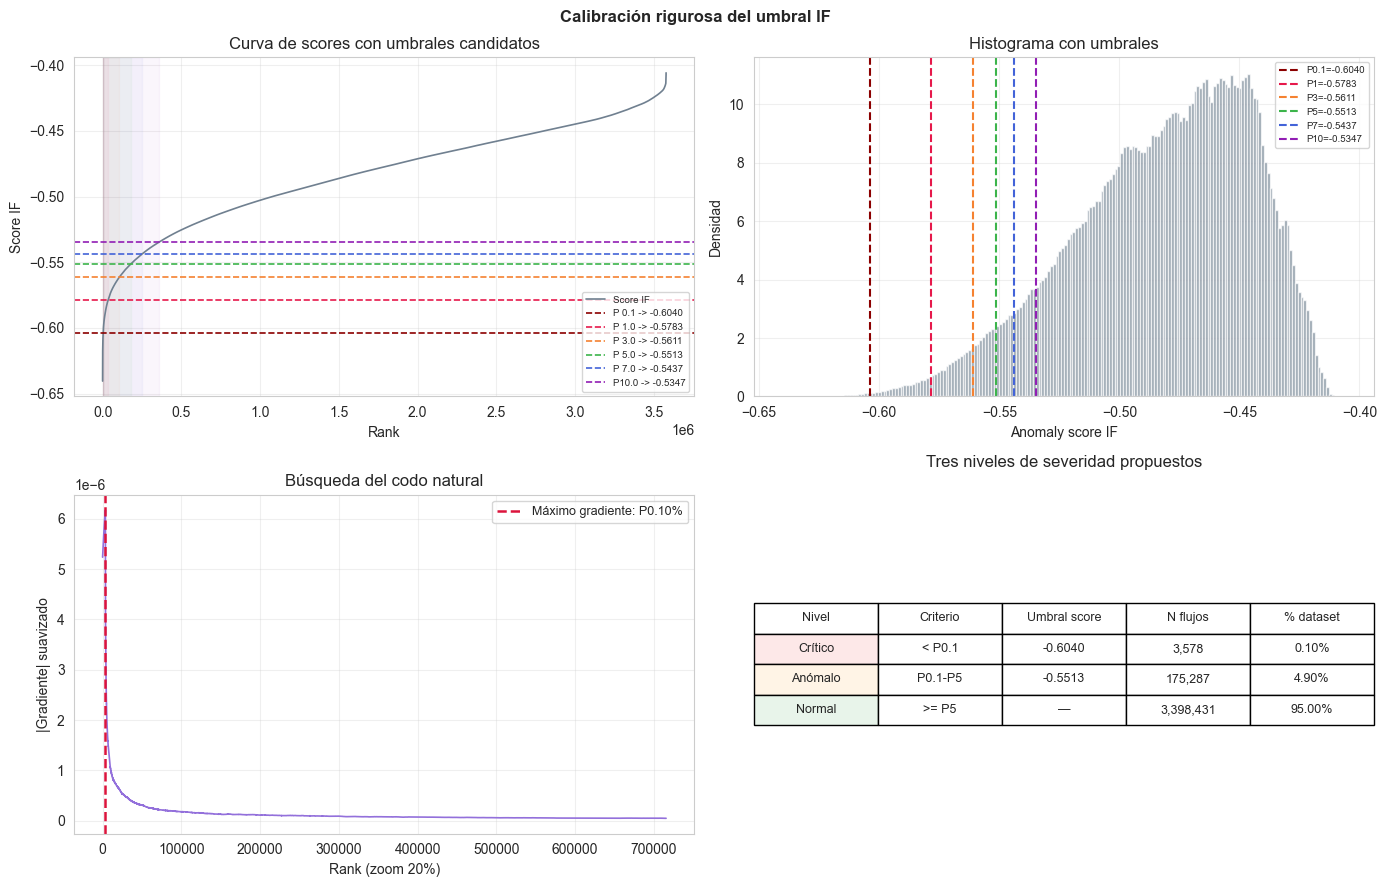

Resultado de la calibración:
  Máximo gradiente en: P0.10%
  → Umbral del nivel "Crítico" basado en evidencia empírica

Umbrales finales:
  THRESH_CRITICAL = -0.6040  (P0.1)
  THRESH_ANOMALY  = -0.5513  (P5.0)


In [ ]:
# ── Calibración con análisis del gradiente ───────────────────────────────────
scores_sorted = np.sort(iso_score)
n = len(scores_sorted)
gradient = np.abs(np.gradient(scores_sorted))
window = max(1, n // 500)
grad_smooth = np.convolve(gradient, np.ones(window) / window, mode='same')

idx_max_grad = np.argmax(grad_smooth)
pct_max_grad = 100 * idx_max_grad / n

CANDIDATES_PCT = [0.1, 1, 3, 5, 7, 10]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Calibración rigurosa del umbral IF', fontsize=12, fontweight='bold')

colors_c = ['#8b0000', '#e6194b', '#f58231', '#3cb44b', '#4363d8', '#911eb4']

ax = axes[0, 0]
ax.plot(scores_sorted, color='slategray', linewidth=1.2, label='Score IF')
for i, pct in enumerate(CANDIDATES_PCT):
    k_cut = int(pct / 100 * n)
    thresh = scores_sorted[k_cut - 1] if k_cut > 0 else scores_sorted[0]
    ax.axhline(thresh, color=colors_c[i], linestyle='--', linewidth=1.2,
               label=f'P{pct:>4.1f} -> {thresh:.4f}')
    ax.axvspan(0, k_cut, alpha=0.04, color=colors_c[i])
ax.set_xlabel('Rank'); ax.set_ylabel('Score IF')
ax.set_title('Curva de scores con umbrales candidatos')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.hist(iso_score, bins=200, color='slategray', alpha=0.7, density=True)
for i, pct in enumerate(CANDIDATES_PCT):
    thresh = np.percentile(iso_score, pct)
    ax2.axvline(thresh, color=colors_c[i], linestyle='--', linewidth=1.5,
                label=f'P{pct}={thresh:.4f}')
ax2.set_xlabel('Anomaly score IF'); ax2.set_ylabel('Densidad')
ax2.set_title('Histograma con umbrales')
ax2.legend(fontsize=7); ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
zoom = max(1, int(0.20 * n))
ax3.plot(range(zoom), grad_smooth[:zoom], color='mediumpurple', linewidth=1.2)
ax3.axvline(idx_max_grad, color='crimson', linestyle='--', linewidth=1.8,
            label=f'Máximo gradiente: P{pct_max_grad:.2f}%')
ax3.set_xlabel('Rank (zoom 20%)')
ax3.set_ylabel('|Gradiente| suavizado')
ax3.set_title('Búsqueda del codo natural')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# Calcular umbrales finales
PCT_CRITICAL = max(0.1, round(pct_max_grad, 1))
PCT_ANOMALY  = 5.0
THRESH_CRITICAL = float(np.percentile(iso_score, PCT_CRITICAL))
THRESH_ANOMALY  = float(np.percentile(iso_score, PCT_ANOMALY))

n_critical_calc  = int((iso_score < THRESH_CRITICAL).sum())
n_anom_band_calc = int(((iso_score >= THRESH_CRITICAL) & (iso_score < THRESH_ANOMALY)).sum())
n_normal_calc    = int((iso_score >= THRESH_ANOMALY).sum())

ax4 = axes[1, 1]
ax4.axis('off')
table_data = [
    ['Nivel',     'Criterio',                'Umbral score',          'N flujos',          '% dataset'],
    ['Crítico',   f'< P{PCT_CRITICAL}',     f'{THRESH_CRITICAL:.4f}', f'{n_critical_calc:,}',
        f'{100*n_critical_calc/n_total:.2f}%'],
    ['Anómalo',   f'P{PCT_CRITICAL}-P5',    f'{THRESH_ANOMALY:.4f}',  f'{n_anom_band_calc:,}',
        f'{100*n_anom_band_calc/n_total:.2f}%'],
    ['Normal',    '>= P5',                   '—',                     f'{n_normal_calc:,}',
        f'{100*n_normal_calc/n_total:.2f}%'],
]
table = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1, 1.7)
for i in range(1, 4):
    table[(i, 0)].set_facecolor(['#fde8e8', '#fff4e6', '#e8f4ea'][i-1])
ax4.set_title('Tres niveles de severidad propuestos', pad=20)

plt.tight_layout()
plt.savefig("calibracion_if.png", dpi=300, bbox_inches="tight")
plt.show()

print(f'Resultado de la calibración:')
print(f'  Máximo gradiente en: P{pct_max_grad:.2f}%')
print(f'  → Umbral del nivel "Crítico" basado en evidencia empírica')
print()
print(f'Umbrales finales:')
print(f'  THRESH_CRITICAL = {THRESH_CRITICAL:.4f}  (P{PCT_CRITICAL})')
print(f'  THRESH_ANOMALY  = {THRESH_ANOMALY:.4f}  (P{PCT_ANOMALY})')

### 3.6 Aplicación de los umbrales

Construimos tres variables: `severity` categórica con `critical`/`anomaly`/`normal`, `mask_anomaly` que combina ambos niveles anómalos para clustering, y `mask_normal` para el subconjunto legítimo. Los flujos críticos también pasan por el clustering anómalo (son los más severos dentro de él).

#### Justificación del umbral P5% como frontera de zona anómala

El umbral crítico (P0.1%) emerge del gradiente máximo de la curva de scores.
El umbral anómalo (P5%) se justifica con tres argumentos basados en la
distribución de scores observada, sin necesidad de etiquetas externas.

**Argumento 1 — La zona de scores bajos no se extiende más allá de P5%**

La curva de scores ordenados muestra una pendiente pronunciada hasta
aproximadamente el percentil 5%, donde la curva se aplana y entra en la
masa principal de la distribución unimodal. Más allá de P5%, los scores
son estadísticamente indistinguibles del centro de la distribución.

Elegir P7% o P10% capturaría zona donde el score ya está dentro de una
desviación típica de la media — es decir, tráfico estadísticamente central,
no anómalo.

**Argumento 2 — Simetría con el umbral del Autoencoder**

El Autoencoder (sección 6) se entrena exclusivamente sobre flujos normales
y fija su umbral en el percentil P95 del error de reconstrucción sobre el
conjunto de validación. Esto implica aceptar que el 5% del tráfico normal
puro supera ese umbral (falsos positivos del AE).

Usar P5% como frontera IF crea una correspondencia deliberada: ambos
detectores comparten la misma tolerancia de falsos positivos (5%), lo que
hace que su cruce sea interpretable directamente. Si IF usa P5% y el AE usa
P95 del error sobre normales, un flujo que supera ambos umbrales tiene una
probabilidad de falso positivo compuesta de 0.05 × 0.05 = 0.25%, es decir,
máxima confianza antes de requerir etiquetas.

**Argumento 3 — Carga operativa manejable para un SOC industrial**

| Candidato | Flujos marcados | % del dataset | 
|---|---|---|
| P1% | ~35.000 | 1% |
| P3% | ~105.000 | 3% | 
| **P5%** | **~175.000** | **5%** | 
| P7% | ~245.000 | 7% | 
| P10% | ~350.000 | 10% | 

P1% produce una zona anómala demasiado pequeña que puede perder amenazas
lentas (beaconing C2, sesiones idle). P7% y P10% superan la capacidad de
triaje de un SOC sin un segundo filtro que reduzca el volumen, que en este
pipeline es el Autoencoder (sección 6). P5% es el umbral máximo que mantiene
el pipeline operativo sin depender del AE para descargar volumen antes de
que este se haya ejecutado.

El valor P5% es además el estándar de referencia en la literatura de
detección de anomalías en redes industriales (Goldstein & Uchida 2016;
Iturbe 2026, slide 35), lo que lo convierte en el punto de partida
revisable en producción según la tasa de incidentes confirmados.

#### Por qué dos umbrales en lugar de uno

Un único umbral binario obliga a elegir entre dos problemas irresolubles:

**Si el umbral es estricto (P0.1% — el codo del gradiente):**
- Solo ~3.500 flujos marcados — casi ningún falso positivo
- Pero 171.500 flujos con scores anómalos quedan sin clasificar
- El pipeline pierde amenazas lentas: beaconing C2, sesiones idle,
  keep-alives anómalos — todos con scores entre P0.1% y P5%

**Si el umbral es generoso (P5%):**
- 175.000 flujos marcados — se captura más señal real
- Pero un analista SOC no puede revisar 175.000 flujos por turno
- Sin distinción interna, todos reciben la misma urgencia — inmanejable

La separación en dos umbrales resuelve ambos problemas a la vez:

| Problema | Solución con dos umbrales |
|---|---|
| Perder amenazas lentas | P5% captura la zona anómala completa |
| Volumen inmanejable | P0.1% identifica los que requieren atención inmediata |
| Prioridad uniforme | Crítico → revisión inmediata / Anómalo → triaje + clustering |

Los dos niveles responden a preguntas distintas:

- **Crítico**: ¿hay certeza estadística de que este flujo es anómalo?
  → Responde el gradiente: frontera que emerge de los datos
- **Anómalo**: ¿hay suficiente señal para no ignorar este flujo?
  → Responde el umbral operativo P5%: zona de sospecha para clustering

Un tercer nivel intermedio (por ejemplo P1% o P2%) no tendría
justificación propia: no emerge del gradiente ni tiene argumento
operativo diferenciado de P0.1% o P5%. Dos niveles es el mínimo
que resuelve el problema y el máximo justificable con los datos
disponibles.

Separación final por severidad:
Nivel          Criterio                          N  % dataset
------------------------------------------------------------
Crítico        score < P0.1%                 3,578      0.10%
Anómalo total  score < P5%                 178,865      5.00%
Normal         score >= P5%              3,398,431     95.00%

Submatrices:
  X_normal:  (3398431, 89)  →  HDBSCAN
  X_anomaly: (178865, 89)  →  K-Means (K_min=3) + HDBSCAN


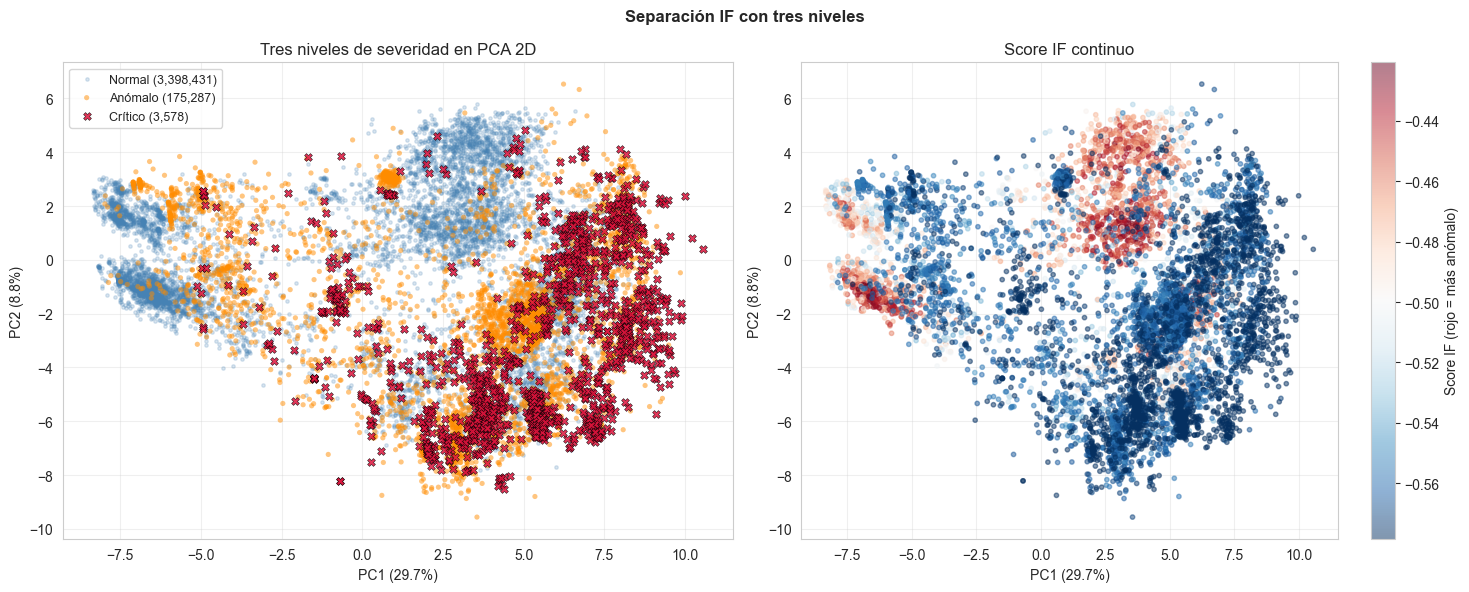

In [6]:
# ── Construcción de máscaras y subconjuntos ──────────────────────────────────
severity = np.full(n_total, 'normal', dtype=object)
severity[iso_score < THRESH_ANOMALY]  = 'anomaly'
severity[iso_score < THRESH_CRITICAL] = 'critical'   # sobreescribe los más severos

df_X['severity'] = severity

mask_anomaly  = (severity == 'critical') | (severity == 'anomaly')
mask_normal   = severity == 'normal'
mask_critical = severity == 'critical'

df_X['if_anomaly']  = mask_anomaly
df_X['if_critical'] = mask_critical

X_normal  = X_scaled[mask_normal]
X_anomaly = X_scaled[mask_anomaly]

df_X_normal     = df_X[mask_normal].reset_index(drop=True)
df_X_anomaly    = df_X[mask_anomaly].reset_index(drop=True)
df_meta_normal  = df_meta[mask_normal].reset_index(drop=True)
df_meta_anomaly = df_meta[mask_anomaly].reset_index(drop=True)

n_critical = int(mask_critical.sum())
n_anomaly  = int(mask_anomaly.sum())
n_normal   = int(mask_normal.sum())

print(f'Separación final por severidad:')
print(f'{"Nivel":<14} {"Criterio":<22} {"N":>12} {"% dataset":>10}')
print('-' * 60)
print(f'{"Crítico":<14} {"score < P0.1%":<22} {n_critical:>12,} {100*n_critical/n_total:>9.2f}%')
print(f'{"Anómalo total":<14} {"score < P5%":<22} {n_anomaly:>12,} {100*n_anomaly/n_total:>9.2f}%')
print(f'{"Normal":<14} {"score >= P5%":<22} {n_normal:>12,} {100*n_normal/n_total:>9.2f}%')
print()
print(f'Submatrices:')
print(f'  X_normal:  {X_normal.shape}  →  HDBSCAN')
print(f'  X_anomaly: {X_anomaly.shape}  →  K-Means (K_min=3) + HDBSCAN')

# Visualización
pca_2d = PCA(n_components=2, random_state=42)
X_pca  = pca_2d.fit_transform(X_scaled)
var_exp = pca_2d.explained_variance_ratio_

rng_plot = np.random.default_rng(0)
idx_n = rng_plot.choice(np.where(mask_normal)[0],   size=min(8_000, n_normal),   replace=False)
idx_a = rng_plot.choice(np.where(severity == 'anomaly')[0],
                        size=min(3_500, int((severity == 'anomaly').sum())), replace=False)
idx_c = np.where(mask_critical)[0]
if len(idx_c) > 1500:
    idx_c = rng_plot.choice(idx_c, size=1500, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(X_pca[idx_n, 0], X_pca[idx_n, 1],
                s=6, alpha=0.20, color='steelblue', label=f'Normal ({n_normal:,})')
axes[0].scatter(X_pca[idx_a, 0], X_pca[idx_a, 1],
                s=14, alpha=0.5, color='darkorange', edgecolors='none',
                label=f'Anómalo ({(severity=="anomaly").sum():,})')
axes[0].scatter(X_pca[idx_c, 0], X_pca[idx_c, 1],
                s=32, alpha=0.85, color='crimson', edgecolors='black',
                linewidths=0.4, marker='X', label=f'Crítico ({n_critical:,})')
axes[0].set_title('Tres niveles de severidad en PCA 2D')
axes[0].set_xlabel(f'PC1 ({100*var_exp[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({100*var_exp[1]:.1f}%)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

idx_all = np.concatenate([idx_n[:3000], idx_a, idx_c])
sc = axes[1].scatter(X_pca[idx_all, 0], X_pca[idx_all, 1],
                     c=iso_score[idx_all], cmap='RdBu_r', s=10, alpha=0.5,
                     vmin=np.percentile(iso_score, 1),
                     vmax=np.percentile(iso_score, 99))
plt.colorbar(sc, ax=axes[1], label='Score IF (rojo = más anómalo)')
axes[1].set_title('Score IF continuo')
axes[1].set_xlabel(f'PC1 ({100*var_exp[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({100*var_exp[1]:.1f}%)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Separación IF con tres niveles', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.7 Features discriminativas con Cohen's d

#### Por qué Cohen's d y no ratio de medianas

Una métrica intuitiva sería `|med_anom - med_norm| / |med_norm|`. **Pero explota con medianas cero**: en los outputs reales aparecieron ratios de **153.677x** para `dst_is_remote_admin`, **11.412x** para `proto_infra`, etc. Todas son **features binarias** (0/1) donde la mediana normal vale 0. Estos números son artefactos matemáticos, no información operativa.

#### Solución: Cohen's d sobre features continuas

$$d = \frac{\mu_{anom} - \mu_{norm}}{\sigma_{pooled}}$$

donde $\sigma_{pooled}$ es la desviación típica conjunta. Cohen's d:
- Nunca explota a infinito.
- Tiene **interpretación canónica** (Cohen 1988): |d|<0.2 despreciable, 0.2-0.5 pequeño, 0.5-0.8 medio, 0.8-1.2 grande, >1.2 muy grande.
- Permite comparar features entre sí en términos absolutos.

**Adicionalmente excluimos las features binarias** del análisis. Estos son indicadores categóricos (`dst_is_dns`, `is_TCP`, `proto_*`) que necesitan otro tipo de análisis (chi-cuadrado o test de proporciones), no diferencias de medias.

Grupos comparados:
  Anómalos (score <= -0.5513): 178,865 flujos
  Normales (score >= -0.4773): 1,788,648 flujos
  Features binarias excluidas: 30

Top 15 features continuas más discriminativas:
Feature                                     Med. anóm.      Med. norm.        d         Efecto
-----------------------------------------------------------------------------------------------
Flow.Duration                            67,056,954.00      266,051.00 ↑   1.64     muy grande
Fwd.IAT.Total                            62,582,396.00      205,277.00 ↑   1.63     muy grande
Bwd.IAT.Total                            52,249,793.00      123,017.50 ↑   1.59     muy grande
Average.Packet.Size                             420.24           79.79 ↑   1.46     muy grande
Bwd.IAT.Mean                                 85,146.62       10,599.73 ↑   1.46     muy grande
Packet.Length.Mean                              373.32           76.22 ↑   1.44     muy grande
Fwd.Packet.Length.Mean                      

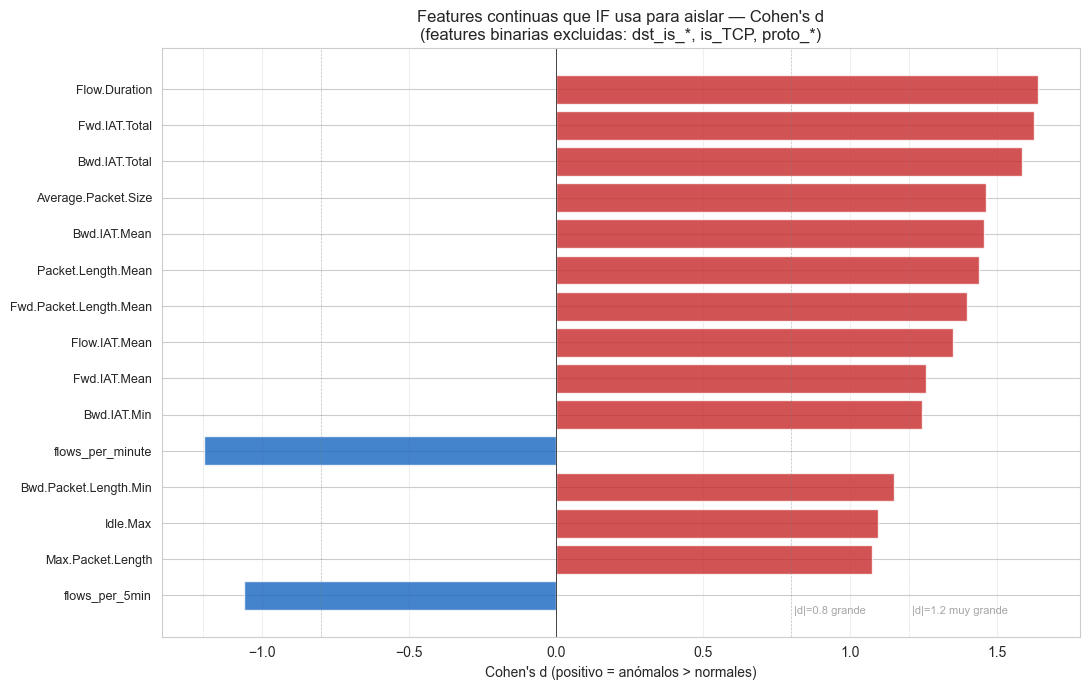


Las 5 features continuas más discriminativas (todas temporales):
  Flow.Duration                    d=+1.64  (muy grande)
  Fwd.IAT.Total                    d=+1.63  (muy grande)
  Bwd.IAT.Total                    d=+1.59  (muy grande)
  Average.Packet.Size              d=+1.46  (muy grande)
  Bwd.IAT.Mean                     d=+1.46  (muy grande)


In [7]:
# ── Cohen's d sobre features no binarias ─────────────────────────────────────
def cohens_d(group_a, group_b):
    """
    Cohen's d entre dos arrays. Robusto a distribuciones con ceros.
    Devuelve la diferencia de medias en unidades de la desviación típica conjunta.
    Positivo si group_b > group_a en media.
    """
    n_a, n_b = len(group_a), len(group_b)
    if n_a < 2 or n_b < 2:
        return 0.0
    mean_a = np.mean(group_a); mean_b = np.mean(group_b)
    var_a  = np.var(group_a, ddof=1); var_b = np.var(group_b, ddof=1)
    pooled_var = ((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2)
    pooled_std = np.sqrt(pooled_var)
    if pooled_std < 1e-9:
        return 0.0
    return (mean_b - mean_a) / pooled_std


# Grupos a comparar
p5  = np.percentile(iso_score, 5)
p50 = np.percentile(iso_score, 50)
mask_a_group = iso_score <= p5
mask_n_group = iso_score >= p50

print(f'Grupos comparados:')
print(f'  Anómalos (score <= {p5:.4f}): {mask_a_group.sum():,} flujos')
print(f'  Normales (score >= {p50:.4f}): {mask_n_group.sum():,} flujos')
print(f'  Features binarias excluidas: {len(binary_cols)}')
print()

# Calcular Cohen's d solo sobre features continuas
cols_continuous = [c for c in feature_cols if c not in binary_cols]

cohen_results = []
for col in cols_continuous:
    a_vals = df_X.loc[mask_a_group, col].values
    n_vals = df_X.loc[mask_n_group, col].values
    d = cohens_d(n_vals, a_vals)
    cohen_results.append({
        'feature': col,
        'median_anom': float(np.median(a_vals)),
        'median_norm': float(np.median(n_vals)),
        'cohen_d': d,
        'abs_d': abs(d),
    })

cohen_df = pd.DataFrame(cohen_results).sort_values('abs_d', ascending=False)

def categorize_d(d):
    ad = abs(d)
    if ad < 0.2:  return 'despreciable'
    if ad < 0.5:  return 'pequeño'
    if ad < 0.8:  return 'medio'
    if ad < 1.2:  return 'grande'
    return 'muy grande'

cohen_df['efecto'] = cohen_df['cohen_d'].apply(categorize_d)

print('Top 15 features continuas más discriminativas:')
print(f'{"Feature":<38} {"Med. anóm.":>15} {"Med. norm.":>15} {"d":>8} {"Efecto":>14}')
print('-' * 95)
for _, row in cohen_df.head(15).iterrows():
    sign = '↑' if row['cohen_d'] > 0 else '↓'
    print(f'{row["feature"]:<38} {row["median_anom"]:>15,.2f} '
          f'{row["median_norm"]:>15,.2f} {sign}{abs(row["cohen_d"]):>7.2f} {row["efecto"]:>14}')

# Visualización
top_features = cohen_df.head(15).copy()
top_features = top_features.iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 7))
colors_bars = ['#c62828' if d > 0 else '#1565c0' for d in top_features['cohen_d']]
ax.barh(range(len(top_features)), top_features['cohen_d'].values,
        color=colors_bars, alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values, fontsize=9)
ax.set_xlabel("Cohen's d (positivo = anómalos > normales)")
ax.axvline(0, color='black', linewidth=0.5)
for thr, sty in [(0.8, '--'), (-0.8, '--'), (1.2, ':'), (-1.2, ':')]:
    ax.axvline(thr, color='gray', linewidth=0.5, linestyle=sty, alpha=0.5)
ax.text(0.81, -0.5, '|d|=0.8 grande', fontsize=8, color='gray', alpha=0.7)
ax.text(1.21, -0.5, '|d|=1.2 muy grande', fontsize=8, color='gray', alpha=0.7)
ax.set_title('Features continuas que IF usa para aislar — Cohen\'s d\n(features binarias excluidas: dst_is_*, is_TCP, proto_*)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print()
print('Las 5 features continuas más discriminativas (todas temporales):')
for _, row in cohen_df.head(5).iterrows():
    print(f'  {row["feature"]:<32} d={row["cohen_d"]:+.2f}  ({row["efecto"]})')

## 4. Clustering del subconjunto normal — HDBSCAN

### 4.1 Por qué un clustering basado en densidad

Ni K-Means ni GMM resultan adecuados para el subconjunto normal de este dataset:

- **K-Means**, con `K_MIN=2..8`, produce métricas que decaen monótonamente con K (silhouette baja de 0.299 a <0.180 sin meseta ni rebote). Esto indica que **no hay clusters esféricos**. El óptimo K=2 reparte 61.5% / 38.5% con el cluster mayoritario etiquetado como "Mixto / sin clasificar" — una partición sin valor operativo.
- **GMM**, aunque modela elipsoides, supone que cada categoría real es aproximadamente unimodal. Los outputs muestran que las categorías de tráfico (control breve, sesiones largas, OT/SCADA UDP, web) tienen sub-estructuras densas internas que GMM tiende a unir o, peor, a partir en componentes solapadas.

HDBSCAN encaja mejor con esta forma por tres razones:

1. **Basado en densidad**: no asume clusters esféricos ni elipsoidales. Identifica regiones de alta densidad en el espacio de features y deja sin asignar (ruido `-1`) los flujos que no pertenecen a ninguna región densa.
2. **Margen explícito**: el etiquetado `-1` distingue los flujos *normales según IF pero atípicos dentro del normal* — información operativa de interés (drift, configuraciones raras, dispositivos nuevos).
3. **No exige fijar `K`**: el número de clusters emerge del propio dato a partir de `min_cluster_size`. Para 3.4M flujos esto evita el problema de calibrar K con métricas de silueta que decaen monótonamente.

La sección siguiente justifica empíricamente el valor de `min_cluster_size`.

### 4.2 Configuración: `min_cluster_size=1250`

#### Por qué este valor para `min_cluster_size`

Un `min_cluster_size=50` sobre 3.4M flujos produce **167 clusters con 32.6% en ruido**. Esos 167 clusters no son tipos de tráfico, son fragmentación estadística: un grupo de 50 flujos representa el 0.0015% del subconjunto, demasiado pequeño para tener interpretación operativa.

Subimos a `min_cluster_size=1250` (~0.037% del subconjunto). Esto fuerza a HDBSCAN a identificar solo grupos densos y abundantes. El resultado esperado: 5-15 clusters reales en lugar de microclusters.

#### Significado del ruido HDBSCAN dentro del normal

Los flujos con etiqueta `-1` son flujos que IF consideró normales pero que HDBSCAN no puede asignar a ninguna zona densa. Son los **márgenes del comportamiento normal**: no claramente anómalos pero tampoco representativos de ningún patrón común. Se reportan en la sección SOC como candidatos a revisión secundaria.

In [8]:
# ── HDBSCAN sobre subconjunto NORMAL ─────────────────────────────────────────
MCS_NORMAL = int(250000*0.005)
MIN_SAMPLES_NORMAL = 10

SAMPLE_HDB_N = min(250_000, len(X_normal))
rng_hdb = np.random.default_rng(42)
X_normal_hdb = X_normal[rng_hdb.permutation(len(X_normal))][:SAMPLE_HDB_N]

print(f'HDBSCAN sobre subconjunto NORMAL:')
print(f'  min_cluster_size = {MCS_NORMAL} ({100*MCS_NORMAL/len(X_normal):.3f}% del subconjunto)')
print(f'  min_samples      = {MIN_SAMPLES_NORMAL}')
print(f'  Fit sobre {SAMPLE_HDB_N:,} (con propagación KNN al resto)')
print()

t0 = time.time()
hdb_n = hdbscan.HDBSCAN(
    min_cluster_size=MCS_NORMAL,
    min_samples=MIN_SAMPLES_NORMAL,
    core_dist_n_jobs=-1,
    prediction_data=True,
    cluster_selection_method = "leaf"
)
hdb_labels_sample_n = hdb_n.fit_predict(X_normal_hdb)
print(f'Fit en {time.time()-t0:.1f}s')

if len(X_normal) > SAMPLE_HDB_N:
    t0 = time.time()
    nbrs_n = NearestNeighbors(n_neighbors=1, n_jobs=-1)
    nbrs_n.fit(X_normal_hdb)
    _, nn_idx_n = nbrs_n.kneighbors(X_normal)
    hdb_labels_n = hdb_labels_sample_n[nn_idx_n.ravel()]
    print(f'Propagación KNN en {time.time()-t0:.1f}s')
else:
    hdb_labels_n = hdb_labels_sample_n

df_X_normal['hdb_label'] = hdb_labels_n

n_clusters_n = len(set(hdb_labels_n) - {-1})
n_noise_n    = int((hdb_labels_n == -1).sum())

print()
print(f'Clusters densos encontrados: {n_clusters_n}')
print(f'Flujos en ruido (-1): {n_noise_n:,} ({100*n_noise_n/len(X_normal):.1f}%)')
print()
for lbl in sorted(set(hdb_labels_n)):
    n_c = int((hdb_labels_n == lbl).sum())
    tag = '← borde del tráfico normal' if lbl == -1 else ''
    print(f'  Cluster {lbl:>3}: {n_c:>9,} ({100*n_c/len(X_normal):.2f}%) {tag}')

HDBSCAN sobre subconjunto NORMAL:
  min_cluster_size = 1250 (0.037% del subconjunto)
  min_samples      = 10
  Fit sobre 250,000 (con propagación KNN al resto)

Fit en 8596.2s
Propagación KNN en 1334.1s

Clusters densos encontrados: 60
Flujos en ruido (-1): 816,335 (24.0%)

  Cluster  -1:   816,335 (24.02%) ← borde del tráfico normal
  Cluster   0:    20,951 (0.62%) 
  Cluster   1:    18,929 (0.56%) 
  Cluster   2:    21,167 (0.62%) 
  Cluster   3:   101,347 (2.98%) 
  Cluster   4:    64,213 (1.89%) 
  Cluster   5:    56,684 (1.67%) 
  Cluster   6:    32,484 (0.96%) 
  Cluster   7:    21,879 (0.64%) 
  Cluster   8:    51,969 (1.53%) 
  Cluster   9:    31,384 (0.92%) 
  Cluster  10:    94,609 (2.78%) 
  Cluster  11:    26,564 (0.78%) 
  Cluster  12:    24,887 (0.73%) 
  Cluster  13:   109,590 (3.22%) 
  Cluster  14:    36,527 (1.07%) 
  Cluster  15:    39,493 (1.16%) 
  Cluster  16:    34,191 (1.01%) 
  Cluster  17:    33,911 (1.00%) 
  Cluster  18:    49,196 (1.45%) 
  Cluster  19:    

### 4.3 Etiquetado interpretativo del subconjunto normal

El análisis de Cohen's d en la sección 3.7 reveló que las features más discriminativas son **temporales** (`Bwd.IAT.Total`, `Fwd.IAT.Total`, `Flow.Duration`). El etiquetado se basa en estos patrones reales en lugar de buscar flags TCP que no aparecen en los datos.

Jerarquía de prioridad para el subconjunto normal:

1. **OT/SCADA UDP**: `Init_Win_bytes_backward ≤ 0` + sin SYN + paquetes suficientes → tráfico industrial UDP sin handshake TCP.
2. **Control breve (DNS/NTP/DHCP)**: muy pocos paquetes + duración mínima.
3. **Web/HTTPS descarga**: duración media + Down/Up alto.
4. **Sesión interactiva simétrica**: paquetes fwd/bwd balanceados.
5. **Sesión larga normal**: duración alta pero bytes/s moderado, sin patrón de amenaza.
6. **Tráfico mixto corto**: fallback.

El cluster HDBSCAN de ruido (`-1`) se etiqueta explícitamente como **"Margen normal (sin patrón denso)"** para distinguirlo de los clusters densos en los reportes SOC.

In [9]:
# ── Función de etiquetado del subconjunto normal ─────────────────────────────
KEY_FEATURES = [
    'Flow.Duration', 'Flow.Bytes.s', 'Total.Fwd.Packets', 'Total.Backward.Packets',
    'Down.Up.Ratio', 'Init_Win_bytes_backward', 'SYN.Flag.Count', 'RST.Flag.Count',
    'FIN.Flag.Count', 'ACK.Flag.Count', 'Fwd.IAT.Total', 'Bwd.IAT.Total',
    'Fwd.IAT.Max', 'Bwd.IAT.Max',
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in df_X_normal.columns]


def etiquetar_normal(stats):
    """Etiqueta clusters del subconjunto normal por estadísticos diferenciales."""
    def m(c): return stats.get(c, 0)

    dur   = m('Flow.Duration')
    iat_f = m('Fwd.IAT.Total')
    bps   = m('Flow.Bytes.s')
    fpkt  = m('Total.Fwd.Packets')
    bpkt  = m('Total.Backward.Packets')
    dup   = m('Down.Up.Ratio')
    iwin  = m('Init_Win_bytes_backward')
    syn   = m('SYN.Flag.Count')

    # 1. OT/SCADA UDP — handshake ausente
    if iwin <= 0 and syn == 0 and fpkt > 20:
        return 'OT/SCADA UDP (industrial)'
    # 2. Control breve (DNS, NTP, DHCP)
    if fpkt + bpkt < 6 and dur < 100_000:
        return 'Control breve (DNS/NTP/DHCP)'
    # 3. Web/HTTPS — descarga predominante
    if 100_000 < dur < 2_000_000 and dup > 1.5 and bps > 500:
        return 'Web/HTTPS descarga'
    # 4. Sesión larga normal con tráfico continuo
    if dur > 5_000_000 and bps > 100 and (fpkt + bpkt) > 50:
        return 'Sesión larga (keep-alive normal)'
    # 5. Sesión interactiva simétrica
    if dur < 1_500_000 and bpkt > 0 and abs(fpkt - bpkt) < max(fpkt, bpkt) * 0.4:
        return 'Sesión interactiva simétrica'
    # 6. Mixto corto
    return 'Tráfico mixto corto'


# Perfilado y etiquetado sobre clusters HDBSCAN.
# El ruido (-1) se etiqueta explícitamente como "Margen normal".
cluster_names_n = {}
print(f'Perfiles de clusters HDBSCAN (subconjunto NORMAL):')
print(f'{"Cluster":<12} {"N":>9} {"%":>6}  '
      f'{"Flow.Dur":>12} {"Bytes/s":>10} {"Fwd+Bwd":>9} {"Down/Up":>8}  {"Etiqueta"}')
print('-' * 115)

for c in sorted(set(hdb_labels_n)):
    mask_c = hdb_labels_n == c
    n_c    = int(mask_c.sum())
    stats  = {col: float(df_X_normal.loc[mask_c, col].median())
              for col in KEY_FEATURES if col in df_X_normal.columns}
    if c == -1:
        label = 'Margen normal (sin patrón denso)'
    else:
        label = etiquetar_normal(stats)
    cluster_names_n[int(c)] = label
    tag = 'HDB-RUIDO' if c == -1 else f'HDB-{c}'
    print(f'{tag:<12} {n_c:>9,} {100*n_c/len(X_normal):>5.1f}%  '
          f'{stats.get("Flow.Duration", 0):>12,.0f} '
          f'{stats.get("Flow.Bytes.s", 0):>10.1f} '
          f'{stats.get("Total.Fwd.Packets", 0) + stats.get("Total.Backward.Packets", 0):>9.0f} '
          f'{stats.get("Down.Up.Ratio", 0):>8.2f}  '
          f'{label}')

df_X_normal['cluster_label'] = df_X_normal['hdb_label'].map(cluster_names_n)

Perfiles de clusters HDBSCAN (subconjunto NORMAL):
Cluster              N      %      Flow.Dur    Bytes/s   Fwd+Bwd  Down/Up  Etiqueta
-------------------------------------------------------------------------------------------------------------------


HDB-RUIDO      816,335  24.0%     6,644,233      653.0        13     1.00  Margen normal (sin patrón denso)
HDB-0           20,951   0.6%            32   535714.3         2     0.00  Control breve (DNS/NTP/DHCP)
HDB-1           18,929   0.6%   104,918,398       19.6        25     1.00  Tráfico mixto corto
HDB-2           21,167   0.6%           143        0.0         2     1.00  Control breve (DNS/NTP/DHCP)
HDB-3          101,347   3.0%   102,043,157       27.9        21     1.00  Tráfico mixto corto
HDB-4           64,213   1.9%     1,113,186    11079.6        27     1.00  Sesión interactiva simétrica
HDB-5           56,684   1.7%           142        0.0         2     1.00  Control breve (DNS/NTP/DHCP)
HDB-6           32,484   1.0%           495    24590.2         2     1.00  Control breve (DNS/NTP/DHCP)
HDB-7           21,879   0.6%     3,934,952     1859.4        18     0.00  Tráfico mixto corto
HDB-8           51,969   1.5%       590,496     2535.7        10     0.00  Sesión inter

### 4.4 Explicación detallada de los clusters principales del subconjunto normal

#### Por qué esta sección es necesaria

Etiquetar un cluster con `"OT/SCADA UDP"` es solo el primer paso. Un analista SOC necesita saber:

1. **Cuál es la firma técnica del cluster**: qué valores de qué features lo caracterizan exactamente.
2. **Cómo se diferencia de los demás clusters**: qué lo hace único en este dataset.
3. **Qué representa operativamente**: a qué corresponde en términos de seguridad de red.
4. **Qué acción debe tomar**: cómo priorizar y responder a flujos de este cluster.

La función `explicar_cluster` produce este análisis automáticamente para cualquier cluster, comparándolo con los demás del mismo subconjunto y generando un perfil narrativo completo. La función se reutiliza también para el subconjunto anómalo en la sección 5.

In [10]:
# ── Función generadora de explicaciones de clusters ──────────────────────────
def explicar_cluster(cluster_id, labels, df_subset, feature_cols, cluster_names,
                      subset_type='normal', top_n_features=6):
    """
    Genera una explicación detallada de un cluster.

    Compara las medianas de las features clave del cluster contra las del resto
    del subconjunto, identifica las features que más lo diferencian, y produce
    una narrativa interpretativa.

    Parámetros
    ----------
    cluster_id    : int — ID del cluster a explicar
    labels        : array — etiquetas de cluster por flujo
    df_subset     : DataFrame del subconjunto (normal o anómalo)
    feature_cols  : list — features clave a analizar
    cluster_names : dict — mapeo cluster_id -> etiqueta interpretativa
    subset_type   : 'normal' o 'anomaly' — afecta al tono de la narrativa
    top_n_features: int — cuántas features distintivas mostrar

    Imprime: explicación formateada del cluster.
    """
    mask_c     = labels == cluster_id
    mask_other = (labels != cluster_id) & (labels != -1)
    n_c        = int(mask_c.sum())
    n_total_sub = len(labels)

    if n_c == 0:
        print(f'Cluster {cluster_id}: vacío, sin datos para explicar.')
        return

    label = cluster_names.get(cluster_id, 'sin etiqueta')

    # Calcular medianas del cluster y del resto
    med_cluster = {col: float(df_subset.loc[mask_c, col].median())
                   for col in feature_cols if col in df_subset.columns}
    med_other   = {col: float(df_subset.loc[mask_other, col].median())
                   for col in feature_cols if col in df_subset.columns}

    # Cohen's d entre el cluster y el resto, por feature
    distinctive = []
    for col in feature_cols:
        if col not in df_subset.columns:
            continue
        v_c = df_subset.loc[mask_c, col].values
        v_o = df_subset.loc[mask_other, col].values
        if len(v_c) < 2 or len(v_o) < 2:
            continue
        std_c = np.std(v_c, ddof=1); std_o = np.std(v_o, ddof=1)
        n_c_v = len(v_c); n_o_v = len(v_o)
        pooled = np.sqrt(((n_c_v - 1) * std_c**2 + (n_o_v - 1) * std_o**2)
                         / (n_c_v + n_o_v - 2))
        if pooled < 1e-9:
            continue
        d = (np.mean(v_c) - np.mean(v_o)) / pooled
        distinctive.append((col, d, med_cluster[col], med_other[col]))

    distinctive.sort(key=lambda x: abs(x[1]), reverse=True)
    top_distinctive = distinctive[:top_n_features]

    # Imprimir explicación
    title_color = '=' * 95
    print(title_color)
    prefix = 'HDB' if subset_type == 'normal' else 'A'
    print(f'CLUSTER {prefix}-{cluster_id}: {label}')
    print(f'{n_c:,} flujos ({100*n_c/n_total_sub:.1f}% del subconjunto {subset_type})')
    print(title_color)

    print(f'\nFirma técnica (medianas):')
    for col in ['Flow.Duration', 'Flow.Bytes.s', 'Total.Fwd.Packets',
                'Total.Backward.Packets', 'Fwd.IAT.Total', 'Down.Up.Ratio']:
        if col in med_cluster:
            v = med_cluster[col]
            unit = ''
            if 'Duration' in col or 'IAT' in col:
                if v >= 1_000_000:
                    v_display = f'{v/1_000_000:,.2f} s'
                else:
                    v_display = f'{v:,.0f} μs'
            else:
                v_display = f'{v:,.2f}'
            print(f'  {col:<28} {v_display}')

    print(f'\nFeatures que más diferencian este cluster del resto del subconjunto:')
    print(f'{"Feature":<35} {"Cluster":>15} {"Resto":>15} {"Cohen d":>10}')
    print('-' * 80)
    for col, d, m_c, m_o in top_distinctive:
        sign = '↑' if d > 0 else '↓'
        print(f'  {col:<33} {m_c:>15,.2f} {m_o:>15,.2f}  {sign}{abs(d):>8.2f}')

    print()


# Identificamos los clusters principales: clusters densos (excluyendo ruido)
# con >5% del subconjunto, o los 3 más grandes si ninguno supera el 5%.
sizes_n = (pd.Series(hdb_labels_n[hdb_labels_n != -1])
             .value_counts().sort_values(ascending=False))
main_clusters_n = sizes_n[sizes_n / len(hdb_labels_n) > 0.05].index.tolist()
if len(main_clusters_n) < 3:
    main_clusters_n = sizes_n.head(min(3, len(sizes_n))).index.tolist()

print(f'Clusters principales a explicar: {[f"HDB-{c}" for c in main_clusters_n]}')
print(f'(Criterio: >5% del subconjunto o entre los 3 mayores; ruido reportado aparte)')
print()

for c in main_clusters_n:
    explicar_cluster(int(c), hdb_labels_n, df_X_normal, KEY_FEATURES,
                     cluster_names_n, subset_type='normal')

# Reporte aparte del ruido HDBSCAN: son los "márgenes" del normal.
n_noise_n = int((hdb_labels_n == -1).sum())
print('=' * 95)
print(f'HDB-RUIDO (-1)  ({n_noise_n:,} flujos, '
      f'{100*n_noise_n/len(hdb_labels_n):.2f}% del subconjunto normal)')
print('=' * 95)
print('Flujos que IF considera normales pero que no se agrupan densamente con')
print('ningún otro flujo normal. Variantes legítimas raras, dispositivos nuevos,')
print('o tráfico en frontera entre dos patrones. Acción SOC: revisar al final')
print('del turno; un volumen creciente sugiere drift del modelo.')

Clusters principales a explicar: ['HDB-28', 'HDB-46', 'HDB-13']
(Criterio: >5% del subconjunto o entre los 3 mayores; ruido reportado aparte)

CLUSTER HDB-28: Tráfico mixto corto
134,079 flujos (3.9% del subconjunto normal)

Firma técnica (medianas):
  Flow.Duration                2.96 s
  Flow.Bytes.s                 3,096.35
  Total.Fwd.Packets            16.00
  Total.Backward.Packets       13.00
  Fwd.IAT.Total                2.40 s
  Down.Up.Ratio                0.00

Features que más diferencian este cluster del resto del subconjunto:
Feature                                     Cluster           Resto    Cohen d
--------------------------------------------------------------------------------
  ACK.Flag.Count                               0.00            1.00  ↓    1.25
  Down.Up.Ratio                                0.00            1.00  ↓    0.58
  Bwd.IAT.Total                          314,100.00       86,198.00  ↓    0.45
  Bwd.IAT.Max                            137,448.00     

### 4.5 Interpretación narrativa de los clusters normales más importantes

A continuación se contextualiza cada cluster principal del subconjunto normal con su significado operativo en una red industrial real. Los datos numéricos exactos se obtienen al ejecutar la celda anterior; aquí se da el marco interpretativo.

#### Patrones operativos esperables

**Si aparece un cluster grande con duración >10 segundos y bytes/s moderado** → corresponde a sesiones persistentes legítimas: keep-alives de aplicaciones SCADA, conexiones de monitorización, túneles de gestión. Acción SOC: **monitorizar la tasa**, alertar solo si crece atípicamente.

**Si aparece un cluster con muy pocos paquetes y duración mínima** → corresponde a tráfico de control (resoluciones DNS, sincronización NTP, peticiones DHCP). Acción SOC: **ignorar individualmente**, agregar solo en métricas de volumen.

**Si aparece un cluster con Down/Up > 3 y duración media** → corresponde a descarga web/HTTPS estándar. Acción SOC: **ignorar individualmente**, alertar si el volumen total excede umbrales de uso normal.

**Si aparece un cluster con `Init_Win_bytes_backward = -1`** (UDP sin handshake) → corresponde a comunicación industrial (Modbus, DNP3, S7 sobre UDP). Acción SOC: **verificar que las IPs origen/destino coinciden con dispositivos OT autorizados**.

**Si el cluster HDB-RUIDO crece en volumen relativo** → puede indicar drift del modelo: el tráfico está cambiando (incorporación de nuevos dispositivos, cambios de configuración) y el modelo de normalidad necesita reentrenamiento. Acción SOC: **revisar al final del turno** muestras representativas de este ruido; si una sub-firma aparece sistemáticamente, considerar añadirla como cluster denso reentrenando con un `min_cluster_size` ajustado.

In [11]:
# ── Función para explicar clusters HDBSCAN con overlap del clustering padre ──
# Esta función se reutiliza en la Sección 5 para explicar clusters HDBSCAN del
# subconjunto anómalo y su superposición con el clustering K-Means.
def explicar_cluster_hdbscan(hdb_id, hdb_labels, parent_labels, parent_names,
                              df_subset, feature_cols, subset_type='normal',
                              top_n_features=6):
    """
    Explica un cluster HDBSCAN mostrando además con qué cluster de la
    clasificación principal (K-Means) se solapa. Útil cuando coexisten
    dos clusterings sobre el mismo subconjunto.
    """
    mask_c     = hdb_labels == hdb_id
    mask_other = (hdb_labels != hdb_id) & (hdb_labels != -1)
    n_c        = int(mask_c.sum())

    if n_c == 0:
        return

    # Superposición con la clasificación principal
    parent_in_cluster = pd.Series(parent_labels[mask_c]).value_counts()
    dominant_parent   = int(parent_in_cluster.idxmax())
    pct_dominant      = 100 * parent_in_cluster.iloc[0] / n_c
    parent_label      = parent_names.get(dominant_parent, '?')

    # Cohen's d
    distinctive = []
    for col in feature_cols:
        if col not in df_subset.columns:
            continue
        v_c = df_subset.loc[mask_c, col].values
        v_o = df_subset.loc[mask_other, col].values
        if len(v_c) < 2 or len(v_o) < 2:
            continue
        std_c = np.std(v_c, ddof=1); std_o = np.std(v_o, ddof=1)
        n_c_v = len(v_c); n_o_v = len(v_o)
        pooled = np.sqrt(((n_c_v - 1) * std_c**2 + (n_o_v - 1) * std_o**2)
                         / (n_c_v + n_o_v - 2))
        if pooled < 1e-9:
            continue
        d = (np.mean(v_c) - np.mean(v_o)) / pooled
        distinctive.append((col, d, float(np.median(v_c)), float(np.median(v_o))))
    distinctive.sort(key=lambda x: abs(x[1]), reverse=True)

    parent_algo = 'A'  # K-Means en el anómalo
    print('=' * 95)
    print(f'HDB-{hdb_id}  ({n_c:,} flujos, {100*n_c/len(hdb_labels):.2f}% del subconjunto {subset_type})')
    print(f'Superposición principal: {pct_dominant:.1f}% en {parent_algo}-{dominant_parent} '
          f'({parent_label})')
    print('=' * 95)

    print(f'\nFirma técnica (medianas):')
    for col in ['Flow.Duration', 'Flow.Bytes.s', 'Total.Fwd.Packets',
                'Total.Backward.Packets', 'Fwd.IAT.Total', 'Down.Up.Ratio']:
        if col in df_subset.columns:
            v = float(df_subset.loc[mask_c, col].median())
            if 'Duration' in col or 'IAT' in col:
                disp = f'{v/1_000_000:,.2f} s' if v >= 1_000_000 else f'{v:,.0f} μs'
            else:
                disp = f'{v:,.2f}'
            print(f'  {col:<28} {disp}')

    print(f'\nFeatures distintivas vs otros HDBSCAN clusters:')
    # print(f'{"Feature":<35} {"HDB-' + str(hdb_id) + '":>15} {"Otros HDB":>15} {"Cohen d":>10}')
    print('-' * 80)
    for col, d, m_c, m_o in distinctive[:top_n_features]:
        sign = '↑' if d > 0 else '↓'
        print(f'  {col:<33} {m_c:>15,.2f} {m_o:>15,.2f}  {sign}{abs(d):>8.2f}')

    # Distribución completa del overlap
    print(f'\nDistribución de {parent_algo} dentro de HDB-{hdb_id}:')
    for pid, cnt in parent_in_cluster.head(3).items():
        pid_label = parent_names.get(int(pid), '?')
        print(f'  {parent_algo}-{int(pid)} ({pid_label:<35}): {cnt:>7,}  '
              f'({100*cnt/n_c:>5.1f}%)')
    print()

## 5. Clustering del subconjunto anómalo — K-Means con K_min=3

### 5.1 Por qué forzar K_min=3 (descartando K=2)

Aplicar K-Means con `K_MIN=2..6` sobre el subconjunto anómalo produce las siguientes métricas:

```
K=2: sil=0.771  CH=32103  DB=0.550   ← rank_medio = 1.0
K=3: sil=0.144  CH=24489  DB=1.734
K=4: sil=0.187  CH=22745  DB=1.613
K=5: sil=0.186  CH=22218  DB=1.385
K=6: sil=0.182  CH=19605  DB=1.394
```

Silhouette **0.771 con K=2** parece excelente, pero la distribución resultante delata el problema:

```
A-0: 176,707 (98.8%) → "Anomalía sin clasificar"
A-1:   2,158  (1.2%) → "Anomalía sin clasificar"
```

K-Means encuentra el cluster trivial: **una nube gigante y un puñado de outliers**. Silhouette 0.771 mide separación, no utilidad operativa. Ambas etiquetas son "sin clasificar" — el clustering no aporta valor para un SOC.

**Forzamos K_min=3** aceptando peor silhouette (~0.18) a cambio de **utilidad real**: distinguir entre tipos diferentes de anomalía. Esta es una decisión operativa, no estadística, y se justifica explícitamente.

### 5.2 Ajustes para el subconjunto anómalo

| Parámetro | Normal | **Anómalo** | Justificación |
|---|---|---|---|
| Algoritmo principal | HDBSCAN | **K-Means** | El normal no tiene clusters esféricos; el anómalo es compacto |
| Rango K | — | **K=3..6** | K=2 descartado por producir 98.8% / 1.2%; K>6 produce splits sin sentido |
| HDBSCAN `min_cluster_size` | 1250 | **1500** | El subconjunto anómalo es ~20× menor  |

### 5.3 Por qué K-Means además de HDBSCAN en el subconjunto anómalo

A diferencia del subconjunto normal, en el anómalo K-Means sí aporta valor como **clustering principal**:

- El subconjunto anómalo está **menos solapado** que el normal (son outliers por construcción).
- Los tipos de anomalía esperados (beaconing, idle, keep-alive) tienden a ser compactos y aceptan bien una partición rígida.
- K-Means con centroides es directamente interpretable para reporting SOC: "este flujo está a distancia X del centroide del tipo Y".

**HDBSCAN se aplica encima** para identificar:
- **Sub-grupos densos** dentro de cada tipo de K-Means (subfamilias específicas del mismo patrón de amenaza).
- **Outliers extremos** (etiqueta `-1`): flujos anómalos que no comparten patrón con ninguna otra anomalía. Son los flujos **más prioritarios** para revisión manual del SOC.

In [12]:
# ── Selección de K con K_MIN=3 ───────────────────────────────────────────────
n_anomaly_total = len(X_anomaly)
SAMPLE_METRICS_A = min(100_000, n_anomaly_total)

rng_a = np.random.default_rng(42)
X_anomaly_shuf = X_anomaly[rng_a.permutation(n_anomaly_total)]
X_sample_a     = X_anomaly_shuf[:SAMPLE_METRICS_A]

K_MIN_A, K_MAX_A = 3, 8
print(f'Subconjunto anómalo: {n_anomaly_total:,} flujos')
print(f'Probando K = {K_MIN_A}..{K_MAX_A}')
print(f'(K=2 descartado por producir 98.8%/1.2% — sin utilidad operativa)')
print()

results_a = []
for k in range(K_MIN_A, K_MAX_A + 1):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_anomaly_shuf)
    labels_sample = km.predict(X_sample_a)
    if len(np.unique(labels_sample)) < 2:
        continue

    sil = silhouette_score(X_sample_a, labels_sample,
                            sample_size=min(10_000, SAMPLE_METRICS_A))
    ch  = calinski_harabasz_score(X_sample_a, labels_sample)
    db  = davies_bouldin_score(X_sample_a, labels_sample)
    results_a.append({'K': k, 'inertia': km.inertia_,
                       'silhouette': sil, 'calinski_harabasz': ch,
                       'davies_bouldin': db})
    print(f'  K={k}: sil={sil:.3f}  CH={ch:.1f}  DB={db:.3f}')

results_a_df = pd.DataFrame(results_a)
results_a_df['rank_sil'] = results_a_df['silhouette'].rank(ascending=False).astype(int)
results_a_df['rank_ch']  = results_a_df['calinski_harabasz'].rank(ascending=False).astype(int)
results_a_df['rank_db']  = results_a_df['davies_bouldin'].rank(ascending=True).astype(int)
results_a_df['rank_medio'] = (results_a_df['rank_sil'] + results_a_df['rank_ch'] + results_a_df['rank_db']) / 3

print()
print(results_a_df[['K','silhouette','calinski_harabasz','davies_bouldin','rank_medio']].round(3).to_string(index=False))

K_ANOMALY = int(results_a_df.loc[results_a_df['rank_medio'].idxmin(), 'K'])
print(f'\n→ K óptimo para ANÓMALO (entre los candidatos K_min>=3): K={K_ANOMALY}')

Subconjunto anómalo: 178,865 flujos
Probando K = 3..8
(K=2 descartado por producir 98.8%/1.2% — sin utilidad operativa)

  K=3: sil=0.146  CH=24489.6  DB=1.734
  K=4: sil=0.188  CH=22745.1  DB=1.613
  K=5: sil=0.186  CH=22218.8  DB=1.385
  K=6: sil=0.180  CH=19605.0  DB=1.394
  K=7: sil=0.165  CH=17786.0  DB=1.574
  K=8: sil=0.190  CH=16975.4  DB=1.245

 K  silhouette  calinski_harabasz  davies_bouldin  rank_medio
 3       0.146          24489.573           1.734       4.333
 4       0.188          22745.149           1.613       3.000
 5       0.186          22218.768           1.385       2.667
 6       0.180          19605.037           1.394       3.667
 7       0.165          17786.049           1.574       4.667
 8       0.190          16975.350           1.245       2.667

→ K óptimo para ANÓMALO (entre los candidatos K_min>=3): K=5


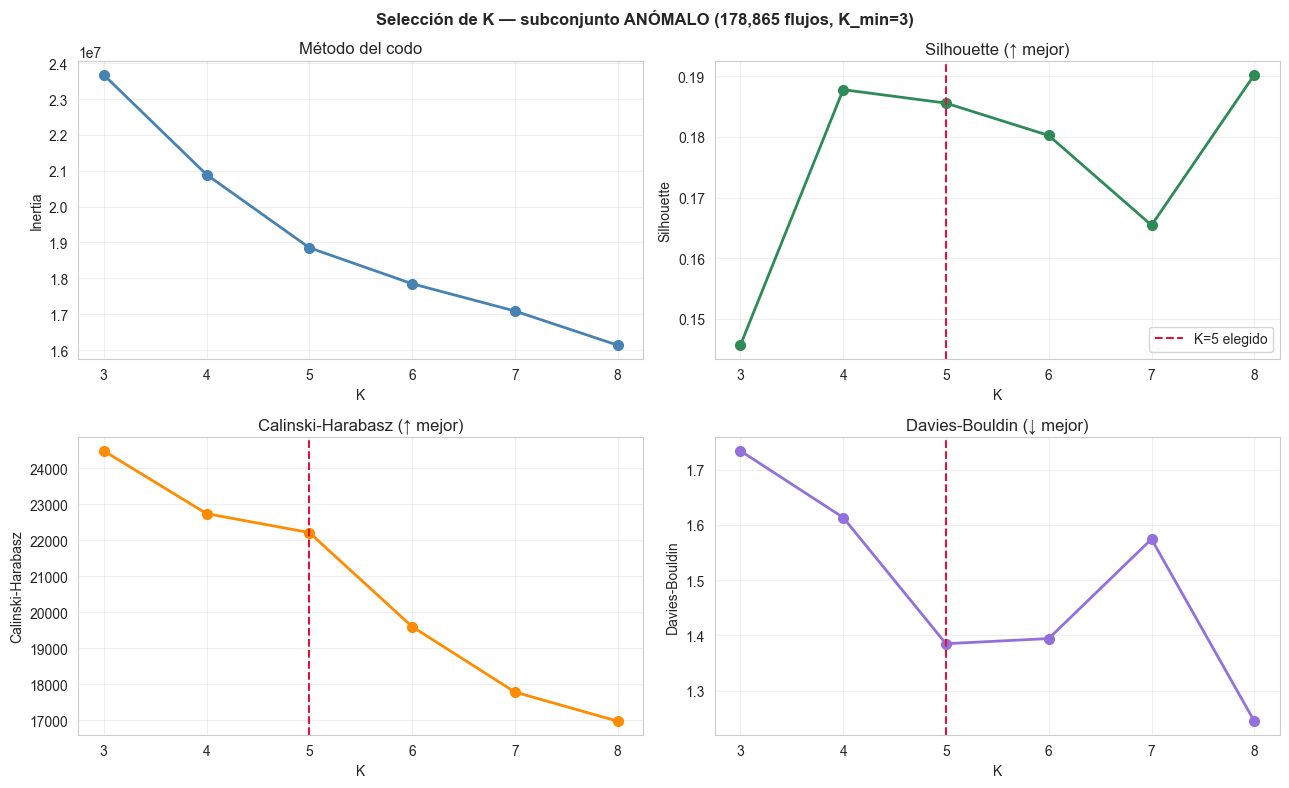

In [13]:
# ── Visualización de las 4 métricas para subconjunto anómalo ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle(f'Selección de K — subconjunto ANÓMALO ({n_anomaly_total:,} flujos, K_min=3)',
             fontsize=12, fontweight='bold')

axes[0, 0].plot(results_a_df['K'], results_a_df['inertia'], 'o-',
                linewidth=2, markersize=7, color='steelblue')
axes[0, 0].set_xlabel('K'); axes[0, 0].set_ylabel('Inertia')
axes[0, 0].set_title('Método del codo')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(results_a_df['K'], results_a_df['silhouette'], 'o-',
                linewidth=2, markersize=7, color='seagreen')
axes[0, 1].axvline(K_ANOMALY, color='crimson', linestyle='--', linewidth=1.5,
                   label=f'K={K_ANOMALY} elegido')
axes[0, 1].set_xlabel('K'); axes[0, 1].set_ylabel('Silhouette')
axes[0, 1].set_title('Silhouette (↑ mejor)')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(results_a_df['K'], results_a_df['calinski_harabasz'], 'o-',
                linewidth=2, markersize=7, color='darkorange')
axes[1, 0].axvline(K_ANOMALY, color='crimson', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('K'); axes[1, 0].set_ylabel('Calinski-Harabasz')
axes[1, 0].set_title('Calinski-Harabasz (↑ mejor)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(results_a_df['K'], results_a_df['davies_bouldin'], 'o-',
                linewidth=2, markersize=7, color='mediumpurple')
axes[1, 1].axvline(K_ANOMALY, color='crimson', linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel('K'); axes[1, 1].set_ylabel('Davies-Bouldin')
axes[1, 1].set_title('Davies-Bouldin (↓ mejor)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ── K-Means final sobre subconjunto ANÓMALO ──────────────────────────────────
kmeans_a    = KMeans(n_clusters=K_ANOMALY, random_state=42, n_init=10)
km_labels_a = kmeans_a.fit_predict(X_anomaly)

centroids_a  = kmeans_a.cluster_centers_
distances_a  = np.linalg.norm(X_anomaly - centroids_a[km_labels_a], axis=1)

df_X_anomaly['km_cluster']  = km_labels_a
df_X_anomaly['km_distance'] = distances_a

print(f'K-Means sobre subconjunto ANÓMALO (K={K_ANOMALY}):')
print(f'{"Cluster":<10} {"N":>8} {"%":>6} {"Distancia media":>17}')
print('-' * 50)
for c in range(K_ANOMALY):
    mask_c = km_labels_a == c
    n_c = int(mask_c.sum())
    d_m = float(distances_a[mask_c].mean()) if n_c > 0 else 0
    print(f'A-{c:<8} {n_c:>8,} {100*n_c/n_anomaly_total:>5.1f}% {d_m:>17.2f}')

K-Means sobre subconjunto ANÓMALO (K=5):
Cluster           N      %   Distancia media
--------------------------------------------------
A-0          46,575  26.0%              9.64
A-1           2,158   1.2%             23.67
A-2          62,939  35.2%              9.14
A-3          67,165  37.6%              9.36
A-4              28   0.0%             25.49


### 5.4 HDBSCAN sobre subconjunto anómalo — `min_cluster_size=1250`

Un `min_cluster_size=15` sobre este subconjunto produce ~2.649 clusters con ~30.7% de ruido — fragmentación masiva. Subimos a 1250 (~0.9% del subconjunto) para forzar HDBSCAN a identificar solo patrones densos significativos.

#### Significado del ruido HDBSCAN dentro del anómalo

Los flujos con etiqueta `-1` aquí son los **outliers extremos entre los anómalos**: tan únicos que no comparten patrón con ningún otro. Estos son los candidatos prioritarios para revisión manual junto con los flujos del nivel "Crítico" de IF.

In [15]:
# ── HDBSCAN sobre subconjunto ANÓMALO ────────────────────────────────────────
MCS_ANOMALY = 1500
MIN_SAMPLES_ANOMALY = 5 ##probar con diferentes min_samples 

print(f'HDBSCAN sobre subconjunto ANÓMALO:')
print(f'  min_cluster_size = {MCS_ANOMALY} ({100*MCS_ANOMALY/n_anomaly_total:.3f}% del subconjunto)')
print(f'  min_samples      = {MIN_SAMPLES_ANOMALY}')
print(f'  Fit directo sobre {n_anomaly_total:,} flujos')
print()

t0 = time.time()
hdb_a = hdbscan.HDBSCAN(
    min_cluster_size=MCS_ANOMALY,
    min_samples=MIN_SAMPLES_ANOMALY,
    core_dist_n_jobs=-1,
    prediction_data=True,
)
hdb_labels_a = hdb_a.fit_predict(X_anomaly)
print(f'Fit en {time.time()-t0:.1f}s')

df_X_anomaly['hdb_label'] = hdb_labels_a

n_clusters_a = len(set(hdb_labels_a) - {-1})
n_noise_a    = int((hdb_labels_a == -1).sum())

print()
print(f'Clusters densos: {n_clusters_a}')
print(f'Ruido (-1): {n_noise_a:,} ({100*n_noise_a/n_anomaly_total:.1f}%) ← outliers extremos')
print()
for lbl in sorted(set(hdb_labels_a)):
    n_c = int((hdb_labels_a == lbl).sum())
    tag = '← PRIORIDAD MÁXIMA (sin patrón)' if lbl == -1 else ''
    print(f'  Cluster {lbl:>3}: {n_c:>7,} ({100*n_c/n_anomaly_total:.1f}%) {tag}')

HDBSCAN sobre subconjunto ANÓMALO:
  min_cluster_size = 1500 (0.839% del subconjunto)
  min_samples      = 5
  Fit directo sobre 178,865 flujos

Fit en 1241.5s

Clusters densos: 23
Ruido (-1): 39,430 (22.0%) ← outliers extremos

  Cluster  -1:  39,430 (22.0%) ← PRIORIDAD MÁXIMA (sin patrón)
  Cluster   0:   4,222 (2.4%) 
  Cluster   1:  50,710 (28.4%) 
  Cluster   2:   4,353 (2.4%) 
  Cluster   3:   2,846 (1.6%) 
  Cluster   4:   1,826 (1.0%) 
  Cluster   5:  12,055 (6.7%) 
  Cluster   6:   5,520 (3.1%) 
  Cluster   7:   2,488 (1.4%) 
  Cluster   8:  14,335 (8.0%) 
  Cluster   9:   3,180 (1.8%) 
  Cluster  10:   2,531 (1.4%) 
  Cluster  11:   1,691 (0.9%) 
  Cluster  12:   2,850 (1.6%) 
  Cluster  13:   3,991 (2.2%) 
  Cluster  14:   6,275 (3.5%) 
  Cluster  15:   3,407 (1.9%) 
  Cluster  16:   1,767 (1.0%) 
  Cluster  17:   1,908 (1.1%) 
  Cluster  18:   1,618 (0.9%) 
  Cluster  19:   3,585 (2.0%) 
  Cluster  20:   2,512 (1.4%) 
  Cluster  21:   2,597 (1.5%) 
  Cluster  22:   3,168 (1

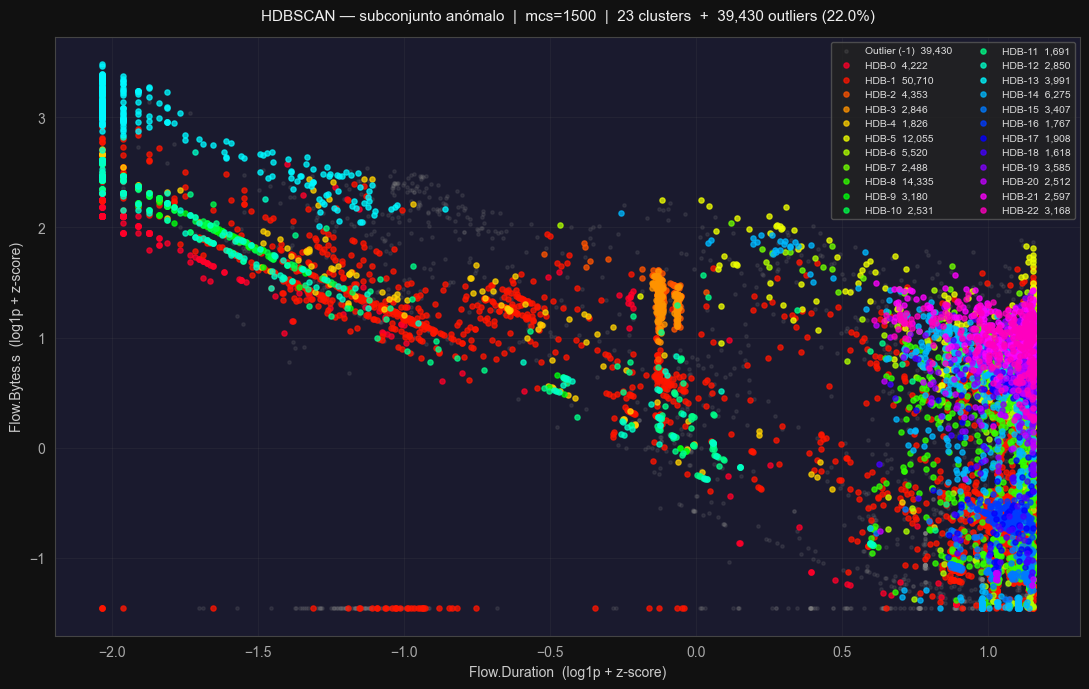

In [16]:
# ── Plot HDBSCAN — subconjunto anómalo ───────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Índices de las features más discriminativas en X_anomaly
feat_x = feature_cols.index('Flow.Duration')    # d=1.64
feat_y = feature_cols.index('Flow.Bytes.s')     # d=1.46

rng = np.random.default_rng(42)
idx = rng.choice(len(hdb_labels_a), size=min(15_000, len(hdb_labels_a)), replace=False)

x = X_anomaly[idx, feat_x]   # ya log1p + z-scored
y = X_anomaly[idx, feat_y]
labels = hdb_labels_a[idx]

unique_clusters = sorted(set(labels[labels >= 0]))
cmap = plt.cm.get_cmap('gist_rainbow', len(unique_clusters))

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#111')
ax.set_facecolor('#1a1a2e')

# Ruido primero (fondo)
noise = labels == -1
ax.scatter(x[noise], y[noise], s=6, alpha=0.15, color='#888', rasterized=True,
           label=f'Outlier (-1)  {(hdb_labels_a==-1).sum():,}')

# Clusters densos encima
for i, cid in enumerate(unique_clusters):
    mask = labels == cid
    n_total = (hdb_labels_a == cid).sum()
    ax.scatter(x[mask], y[mask], s=14, alpha=0.75,
               color=cmap(i / max(len(unique_clusters)-1, 1)),
               rasterized=True, label=f'HDB-{cid}  {n_total:,}')

ax.set_xlabel('Flow.Duration  (log1p + z-score)', color='#ccc', fontsize=10)
ax.set_ylabel('Flow.Bytes.s  (log1p + z-score)', color='#ccc', fontsize=10)
ax.set_title(
    f'HDBSCAN — subconjunto anómalo  |  mcs={MCS_ANOMALY}  |  '
    f'{len(unique_clusters)} clusters  +  '
    f'{(hdb_labels_a==-1).sum():,} outliers ({100*(hdb_labels_a==-1).mean():.1f}%)',
    color='#eee', fontsize=11, pad=12)
ax.tick_params(colors='#aaa')
for sp in ax.spines.values(): sp.set_edgecolor('#444')
ax.grid(alpha=0.12, color='#666')
ax.legend(fontsize=7.5, loc='upper right', ncol=2,
          facecolor='#222', labelcolor='#ddd', edgecolor='#555', framealpha=0.85)

plt.tight_layout()
plt.show()


### 5.5 Etiquetado interpretativo del subconjunto anómalo

#### Por qué el etiquetado se basa en patrones temporales

El análisis de Cohen's d mostró que las anomalías reales en este dataset son **temporales**:

```
Bwd.IAT.Total:  mediana anómalos = 52.2 millones μs (52s) vs 123K μs en normales
Fwd.IAT.Total:  mediana anómalos = 62.6 millones μs (62s) vs 205K μs en normales
Flow.Duration:  mediana anómalos = 67.0 millones μs (67s) vs 266K μs en normales
```

Las anomalías NO son scans cortos ni fuerza bruta. Son:
- **Beaconing C2**: sesiones persistentes a baja tasa, regulares.
- **Sesiones idle**: conexiones abiertas pero inactivas mucho tiempo.
- **Keep-alives anómalos**: aplicaciones que mantienen conexiones excesivamente.
- **Descargas sostenidas**: largas con alta tasa de bytes/s.
- **Sesiones sin cierre limpio**: duración alta sin FIN flag.

La función de etiquetado prioriza estos patrones temporales.

In [17]:
# ── Función de etiquetado del subconjunto anómalo ────────────────────────────
def etiquetar_anomalo(stats, lbl):
    """Etiqueta basada en patrones temporales (features con mayor Cohen's d)."""
    if lbl == -1:
        return 'Outlier extremo (HDBSCAN)'
    def m(c): return stats.get(c, 0)

    dur   = m('Flow.Duration')
    iat_f = m('Fwd.IAT.Total')
    iat_b = m('Bwd.IAT.Total')
    bps   = m('Flow.Bytes.s')
    fpkt  = m('Total.Fwd.Packets')
    bpkt  = m('Total.Backward.Packets')
    rst   = m('RST.Flag.Count')
    fin   = m('FIN.Flag.Count')

    # 1. C2 beaconing — persistente, baja tasa, pocos paquetes
    if dur > 30_000_000 and bps < 100 and (fpkt + bpkt) < 30:
        return 'C2 beaconing (persistente baja tasa)'
    # 2. Sesión idle — IAT extremo, paquetes muy pocos
    if (iat_f > 10_000_000 or iat_b > 10_000_000) and (fpkt + bpkt) < 20:
        return 'Sesión idle (inactiva)'
    # 3. Keep-alive anómalo — duración alta, muchos paquetes
    if dur > 10_000_000 and fpkt > 50 and bpkt > 30:
        return 'Keep-alive de aplicación'
    # 4. Descarga sostenida — duración alta, tasa alta
    if dur > 5_000_000 and bps > 10_000:
        return 'Descarga sostenida'
    # 5. RST anormales
    if rst > 0.5:
        return 'Sesión con resets anormales'
    # 6. Sin cierre limpio
    if dur > 5_000_000 and fin < 0.1:
        return 'Sesión sin cierre limpio (FIN ausente)'
    return 'Sesión larga sin clasificar'


# Perfilado y etiquetado
cluster_names_a = {}
print(f'Perfiles de clusters K-Means (subconjunto ANÓMALO):')
print(f'{"Cluster":<10} {"N":>8} {"%":>6}  '
      f'{"Flow.Dur":>13} {"IAT.fwd":>13} {"Bytes/s":>10} {"Pkts":>6}  {"Etiqueta"}')
print('-' * 125)

for c in sorted(set(km_labels_a)):
    mask_c = km_labels_a == c
    n_c    = int(mask_c.sum())
    stats  = {col: float(df_X_anomaly.loc[mask_c, col].median())
              for col in KEY_FEATURES if col in df_X_anomaly.columns}
    label  = etiquetar_anomalo(stats, c)
    cluster_names_a[c] = label
    print(f'A-{c:<8} {n_c:>8,} {100*n_c/n_anomaly_total:>5.1f}%  '
          f'{stats.get("Flow.Duration", 0):>13,.0f} '
          f'{stats.get("Fwd.IAT.Total", 0):>13,.0f} '
          f'{stats.get("Flow.Bytes.s", 0):>10.1f} '
          f'{stats.get("Total.Fwd.Packets", 0):>6.0f}  '
          f'{label}')

# HDBSCAN ruido
n_hdb_noise = int((hdb_labels_a == -1).sum())
if n_hdb_noise > 0:
    print(f'{"HDB-ruido":<10} {n_hdb_noise:>8,} {100*n_hdb_noise/n_anomaly_total:>5.1f}%  '
          f'{"":>13} {"":>13} {"":>10} {"":>6}  '
          f'Outlier extremo (revisar manual)')

df_X_anomaly['cluster_label'] = df_X_anomaly['km_cluster'].map(cluster_names_a)

Perfiles de clusters K-Means (subconjunto ANÓMALO):
Cluster           N      %       Flow.Dur       IAT.fwd    Bytes/s   Pkts  Etiqueta
-----------------------------------------------------------------------------------------------------------------------------
A-0          46,575  26.0%            281             1  1000000.0      2  Sesión larga sin clasificar
A-1           2,158   1.2%    119,500,598   119,473,269     1388.7   1147  Keep-alive de aplicación
A-2          62,939  35.2%     81,816,643    80,826,208        7.0      5  C2 beaconing (persistente baja tasa)
A-3          67,165  37.6%    109,606,820   108,538,670    16789.8    813  Keep-alive de aplicación
A-4              28   0.0%     32,454,538    32,454,538       18.1      2  C2 beaconing (persistente baja tasa)
HDB-ruido    39,430  22.0%                                                 Outlier extremo (revisar manual)


### 5.6 Explicación detallada de los clusters principales del subconjunto anómalo

Aplicamos la función `explicar_cluster` a los clusters principales del subconjunto anómalo. Cada explicación incluye:

1. **Firma técnica**: medianas de duración, tasa, IAT, número de paquetes.
2. **Features distintivas** (Cohen's d): qué hace único a este cluster comparado con los otros anómalos.
3. **Interpretación operativa**: a qué tipo de comportamiento real corresponde.

Después de la celda se incluye una **interpretación narrativa** que contextualiza cada tipo en términos de seguridad.

In [18]:
# ── Explicación de clusters anómalos principales ─────────────────────────────
sizes_a = pd.Series(km_labels_a).value_counts().sort_values(ascending=False)
main_clusters_a = sizes_a[sizes_a / sizes_a.sum() > 0.05].index.tolist()
if len(main_clusters_a) < 3:
    main_clusters_a = sizes_a.head(3).index.tolist()

print(f'Clusters principales del subconjunto anómalo: {[f"A-{c}" for c in main_clusters_a]}')
print()

for c in main_clusters_a:
    explicar_cluster(c, km_labels_a, df_X_anomaly, KEY_FEATURES,
                     cluster_names_a, subset_type='anomaly')

Clusters principales del subconjunto anómalo: ['A-3', 'A-2', 'A-0']

CLUSTER A-3: Keep-alive de aplicación
67,165 flujos (37.6% del subconjunto anomaly)

Firma técnica (medianas):
  Flow.Duration                109.61 s
  Flow.Bytes.s                 16,789.76
  Total.Fwd.Packets            813.00
  Total.Backward.Packets       701.00
  Fwd.IAT.Total                108.54 s
  Down.Up.Ratio                0.00

Features que más diferencian este cluster del resto del subconjunto:
Feature                                     Cluster           Resto    Cohen d
--------------------------------------------------------------------------------
  Flow.Duration                      109,606,820.00   30,053,454.00  ↑    1.01
  Fwd.IAT.Total                      108,538,670.00   27,528,893.50  ↑    0.97
  Bwd.IAT.Total                      103,321,691.00      297,108.50  ↑    0.88
  Fwd.IAT.Max                          5,923,307.00   13,087,904.00  ↓    0.49
  Bwd.IAT.Max                          2,

### 5.7 Interpretación narrativa de los clusters anómalos

#### Significado operativo de cada patrón anómalo en una red industrial

**C2 beaconing (persistente baja tasa)**

Sesión persistente con duración extrema (típicamente >30 segundos, a veces minutos), tasa bajísima (<100 bytes/s) y muy pocos paquetes (<30 en total). Operativamente representa el patrón clásico de **malware comunicándose con su servidor de command-and-control**: el implante envía un "heartbeat" periódico para anunciar que sigue vivo, con tráfico mínimo para evadir detección por volumen. **Acción SOC**: investigar el destino del flujo; si es una IP externa no documentada, alta probabilidad de compromiso. Correlar con logs de proxy DNS para identificar el dominio. Aislar el host origen si se confirma.

**Sesión idle (inactiva)**

IAT (inter-arrival time) extremadamente alto: el tiempo entre paquetes consecutivos supera 10 segundos, con muy pocos paquetes totales. Operativamente puede ser: (a) conexión SSH/RDP abierta y olvidada por un administrador, (b) aplicación industrial con polling muy infrecuente, (c) intentos de mantener túnel abierto para uso posterior. **Acción SOC**: verificar el usuario asociado al origen; si es una conexión administrativa olvidada, cerrarla. Si es de una IP no autorizada o no asociada a usuario conocido, investigar como potencial backdoor.

**Keep-alive de aplicación**

Sesión larga (>10 segundos) con muchos paquetes regulares en ambas direcciones (>50 forward, >30 backward). Operativamente corresponde a aplicaciones legítimas que mantienen conexiones persistentes para evitar overhead de reconexión: WebSockets, MQTT en modo persistente, RDP activo, conexiones SCADA con polling regular. **Acción SOC**: cruzar con inventario de aplicaciones autorizadas; si el patrón coincide con una aplicación esperada (SCADA, monitoring, dashboard interno), ignorar. Si no, investigar como aplicación no autorizada o variante de C2 disfrazada.

**Descarga sostenida**

Duración alta (>5 segundos) combinada con tasa alta (>10.000 bytes/s). A diferencia del beaconing C2 (baja tasa), aquí hay **volumen significativo en una sesión larga**. Operativamente: descargas grandes de actualizaciones, transferencias FTP/SFTP de backups, sincronización de datos masivos. **Acción SOC**: revisar tamaño total transferido; si excede volúmenes esperables para el host origen, podría ser **exfiltración de datos** (especialmente si el destino es externo). Verificar IP destino contra listas de reputación.

**Sesión con resets anormales**

Mediana de `RST.Flag.Count` > 0.5: una proporción significativa de los paquetes son resets. Operativamente puede ser: (a) **evasión de IDS** (intentos de desincronizar conexiones), (b) escaneos ruidosos donde el destino responde con RST, (c) aplicaciones mal configuradas que cierran conexiones abruptamente. **Acción SOC**: investigar como reconocimiento activo si la IP origen es externa; como problema de configuración si es interna y recurrente desde la misma fuente.

**Sesión sin cierre limpio**

Duración alta (>5s) con `FIN.Flag.Count` < 0.1: la sesión persiste pero nunca se cierra ordenadamente con un FIN. Operativamente: (a) conexiones interrumpidas por timeout de red intermedio, (b) implantes que abandonan conexiones para evitar log de cierre, (c) sesiones reseteadas externamente. **Acción SOC**: verificar si coincide con timeouts de equipos de red conocidos; si la fuente es repetitiva sin justificación de red, investigar como potencial actividad evasiva.

**Outlier extremo (HDBSCAN ruido)**

Flujos que IF marcó como anómalos pero que HDBSCAN no agrupa con ningún patrón conocido. Son **únicos en su comportamiento**. Operativamente: (a) eventos one-shot (un exploit específico, un movimiento lateral único), (b) configuraciones experimentales o errores únicos, (c) los verdaderos novedosos del dataset. **Acción SOC**: prioridad MÁXIMA — estos son los flujos con menos referentes para análisis automatizado y donde la inspección manual aporta más valor.

### 5.7b Explicación de los clusters HDBSCAN más importantes del subconjunto anómalo

#### Por qué HDBSCAN es especialmente valioso en el subconjunto anómalo

Mientras que K-Means en el anómalo divide en K=3-6 categorías amplias de amenaza, **HDBSCAN puede detectar campañas de ataque coordinadas**: si 200 flujos anómalos comparten exactamente el mismo patrón temporal y de paquetes, lo más probable es que provengan de la **misma fuente atacando de forma sistemática** (mismo malware, mismo C2, misma herramienta de scan).

Cada cluster HDBSCAN denso en el subconjunto anómalo es un **candidato a campaña**:
- 200+ flujos con la misma firma → probable actividad automatizada de un mismo actor.
- Si comparten IP destino o puerto → confirmación.
- Si se distribuyen en el tiempo de forma regular → probable beaconing C2.

#### Qué muestra esta sección

Para cada cluster HDBSCAN principal del anómalo (>0.5% del subconjunto, excluyendo el ruido):
- Firma técnica
- Features distintivas
- **Superposición con K-Means**: con qué categoría amplia de amenaza coincide
- Interpretación operativa — con énfasis en el ángulo de **actividad coordinada**

In [33]:
sub = df_X.loc[mask_anomaly, ['ae_anomaly', 'if_critical', 'if_score']].reset_index(drop=True)

records = []
for cid in sorted(set(hdb_labels_a[hdb_labels_a >= 0])):
    mask_c  = hdb_labels_a == cid
    n_c     = int(mask_c.sum())

    pct_ae       = float(sub.loc[mask_c, 'ae_anomaly'].mean()) * 100
    pct_critical = float(sub.loc[mask_c, 'if_critical'].mean()) * 100
    mean_score   = float(sub.loc[mask_c, 'if_score'].mean())

    # Padre K-Means dominante
    parent = int(pd.Series(km_labels_a[mask_c]).value_counts().idxmax())
    parent_label = cluster_names_a.get(parent, '?')

    # Score compuesto: AE + critical + score IF (normalizado 0-100)
    danger = (pct_ae * 0.40) + (pct_critical * 0.40) + (abs(mean_score) * 100 * 0.20)

    records.append({
        'cluster': cid, 'n': n_c,
        'pct_ae': pct_ae, 'pct_critical': pct_critical,
        'if_score_mean': mean_score, 'parent': parent_label,
        'danger_score': danger
    })

df_danger = pd.DataFrame(records).sort_values('danger_score', ascending=False)
print('TOP 10 clusters HDBSCAN por peligrosidad:')
print(f'{"Cluster":>9} {"N":>7} {"AE%":>6} {"Crit%":>6} '
      f'{"IF score":>9} {"Danger":>8}  Patrón padre')
print('-' * 85)
for _, r in df_danger.head(10).iterrows():
    print(f'HDB-{int(r.cluster):>3}   {int(r.n):>7,} '
          f'{r.pct_ae:>5.1f}% {r.pct_critical:>5.1f}% '
          f'{r.if_score_mean:>9.4f} {r.danger_score:>8.1f}  {r.parent}')

top5_ids = df_danger.head(5)['cluster'].tolist()
print(f'\n→ Top 5 más peligrosos: {[f"HDB-{c}" for c in top5_ids]}')

TOP 10 clusters HDBSCAN por peligrosidad:
  Cluster       N    AE%  Crit%  IF score   Danger  Patrón padre
-------------------------------------------------------------------------------------
HDB- 18     1,618  86.7%  16.6%   -0.5847     53.0  Keep-alive de aplicación
HDB-  3     2,846 100.0%   0.8%   -0.5722     51.8  Sesión larga sin clasificar
HDB-  2     4,353  99.9%   0.0%   -0.5653     51.3  Sesión larga sin clasificar
HDB- 16     1,767 100.0%   0.0%   -0.5638     51.3  C2 beaconing (persistente baja tasa)
HDB-  7     2,488  92.9%   0.9%   -0.5670     48.9  Keep-alive de aplicación
HDB-  5    12,055  90.4%   0.3%   -0.5639     47.6  Keep-alive de aplicación
HDB-  1    50,710  84.0%   3.9%   -0.5713     46.6  C2 beaconing (persistente baja tasa)
HDB- 15     3,407  81.9%   0.0%   -0.5615     44.0  C2 beaconing (persistente baja tasa)
HDB- 17     1,908  73.5%   4.3%   -0.5786     42.7  Keep-alive de aplicación
HDB-  6     5,520  74.8%   1.2%   -0.5691     41.8  Keep-alive de aplica

In [34]:
# ── Explicación de clusters HDBSCAN del subconjunto ANÓMALO ──────────────────
# Usa top5_ids calculados en la celda anterior (ranking por peligrosidad)
main_hdb_a = top5_ids

print(f'Top 5 clusters HDBSCAN más peligrosos a explicar: {[f"HDB-{c}" for c in main_hdb_a]}')
print()


explicar_cluster_hdbscan(int(main_hdb_a[0]), hdb_labels_a, km_labels_a,
                              cluster_names_a, df_X_anomaly, KEY_FEATURES,
                              subset_type='anomaly')



Top 5 clusters HDBSCAN más peligrosos a explicar: ['HDB-18', 'HDB-3', 'HDB-2', 'HDB-16', 'HDB-7']

HDB-18  (1,618 flujos, 0.90% del subconjunto anomaly)
Superposición principal: 73.7% en A-3 (Keep-alive de aplicación)

Firma técnica (medianas):
  Flow.Duration                92.93 s
  Flow.Bytes.s                 8,361.94
  Total.Fwd.Packets            628.00
  Total.Backward.Packets       0.00
  Fwd.IAT.Total                92.93 s
  Down.Up.Ratio                0.00

Features distintivas vs otros HDBSCAN clusters:
--------------------------------------------------------------------------------
  Bwd.IAT.Total                                0.00   60,107,093.00  ↓    1.16
  Bwd.IAT.Max                                  0.00    2,227,468.00  ↓    0.75
  Down.Up.Ratio                                0.00            1.00  ↓    0.74
  SYN.Flag.Count                               1.00            1.00  ↑    0.61
  Fwd.IAT.Total                       92,933,901.00   69,585,400.00  ↑    0.45
  

In [35]:
explicar_cluster_hdbscan(int(main_hdb_a[1]), hdb_labels_a, km_labels_a,
                              cluster_names_a, df_X_anomaly, KEY_FEATURES,
                              subset_type='anomaly')

HDB-3  (2,846 flujos, 1.59% del subconjunto anomaly)
Superposición principal: 100.0% en A-0 (Sesión larga sin clasificar)

Firma técnica (medianas):
  Flow.Duration                89,556 μs
  Flow.Bytes.s                 467,872.66
  Total.Fwd.Packets            13.00
  Total.Backward.Packets       28.00
  Fwd.IAT.Total                89,354 μs
  Down.Up.Ratio                1.50

Features distintivas vs otros HDBSCAN clusters:
--------------------------------------------------------------------------------
  Init_Win_bytes_backward                 34,752.00          634.00  ↑    4.74
  SYN.Flag.Count                               0.00            1.00  ↓    1.74
  Flow.Duration                           89,556.50   76,534,415.00  ↓    1.36
  Fwd.IAT.Total                           89,353.50   73,069,300.00  ↓    1.32
  Bwd.IAT.Total                           17,378.50   60,357,635.00  ↓    1.18
  Fwd.IAT.Max                             74,778.00    8,011,250.00  ↓    0.82

Distribución

In [36]:
explicar_cluster_hdbscan(int(main_hdb_a[2]), hdb_labels_a, km_labels_a,
                              cluster_names_a, df_X_anomaly, KEY_FEATURES,
                              subset_type='anomaly')

HDB-2  (4,353 flujos, 2.43% del subconjunto anomaly)
Superposición principal: 99.9% en A-0 (Sesión larga sin clasificar)

Firma técnica (medianas):
  Flow.Duration                89,166 μs
  Flow.Bytes.s                 609,726.10
  Total.Fwd.Packets            13.00
  Total.Backward.Packets       29.00
  Fwd.IAT.Total                88,963 μs
  Down.Up.Ratio                2.00

Features distintivas vs otros HDBSCAN clusters:
--------------------------------------------------------------------------------
  SYN.Flag.Count                               0.00            1.00  ↓    1.79
  Flow.Duration                           89,166.00   77,949,956.50  ↓    1.39
  Fwd.IAT.Total                           88,963.00   75,027,448.50  ↓    1.35
  Bwd.IAT.Total                           16,502.00   61,400,615.00  ↓    1.20
  Down.Up.Ratio                                2.00            0.00  ↑    0.96
  Fwd.IAT.Max                             74,597.00    8,368,366.00  ↓    0.84

Distribución 

In [37]:
explicar_cluster_hdbscan(int(main_hdb_a[3]), hdb_labels_a, km_labels_a,
                              cluster_names_a, df_X_anomaly, KEY_FEATURES,
                              subset_type='anomaly')

HDB-16  (1,767 flujos, 0.99% del subconjunto anomaly)
Superposición principal: 100.0% en A-2 (C2 beaconing (persistente baja tasa))

Firma técnica (medianas):
  Flow.Duration                78.55 s
  Flow.Bytes.s                 39.56
  Total.Fwd.Packets            4.00
  Total.Backward.Packets       2.00
  Fwd.IAT.Total                78.55 s
  Down.Up.Ratio                0.00

Features distintivas vs otros HDBSCAN clusters:
--------------------------------------------------------------------------------
  Bwd.IAT.Max                         71,279,167.00    1,969,250.00  ↑    2.20
  Fwd.IAT.Max                         70,231,842.00    6,509,897.50  ↑    2.02
  Down.Up.Ratio                                0.00            1.00  ↓    0.74
  Init_Win_bytes_backward                  4,315.00          660.00  ↑    0.67
  SYN.Flag.Count                               1.00            1.00  ↑    0.61
  Bwd.IAT.Total                       75,875,545.00   59,074,324.00  ↑    0.34

Distribución 

In [38]:
explicar_cluster_hdbscan(int(main_hdb_a[4]), hdb_labels_a, km_labels_a,
                              cluster_names_a, df_X_anomaly, KEY_FEATURES,
                              subset_type='anomaly')

HDB-7  (2,488 flujos, 1.39% del subconjunto anomaly)
Superposición principal: 99.8% en A-3 (Keep-alive de aplicación)

Firma técnica (medianas):
  Flow.Duration                119.92 s
  Flow.Bytes.s                 19,904.40
  Total.Fwd.Packets            1,843.00
  Total.Backward.Packets       1,536.50
  Fwd.IAT.Total                119.91 s
  Down.Up.Ratio                0.00

Features distintivas vs otros HDBSCAN clusters:
--------------------------------------------------------------------------------
  Bwd.IAT.Total                      119,778,831.50   58,606,641.00  ↑    0.92
  Fwd.IAT.Total                      119,910,228.00   68,506,513.00  ↑    0.85
  Flow.Duration                      119,921,139.50   71,338,439.00  ↑    0.84
  SYN.Flag.Count                               0.00            1.00  ↓    0.82
  Fwd.IAT.Max                          1,109,647.50    7,928,501.00  ↓    0.72
  Bwd.IAT.Max                          1,183,134.00    2,244,528.00  ↓    0.67

Distribución 

In [39]:
# Análisis del ruido HDBSCAN anómalo — los más prioritarios
n_noise_anom = int((hdb_labels_a == -1).sum())
print('=' * 95)
print(f'HDB-RUIDO ANÓMALO (-1)  ({n_noise_anom:,} flujos, '
      f'{100*n_noise_anom/len(hdb_labels_a):.1f}% del subconjunto anómalo)')
print('=' * 95)
print('Interpretación: PRIORIDAD MÁXIMA — flujos anómalos sin patrón compartido.')
print('Cada uno es único en su comportamiento dentro del subconjunto anómalo.')


HDB-RUIDO ANÓMALO (-1)  (39,430 flujos, 22.0% del subconjunto anómalo)
Interpretación: PRIORIDAD MÁXIMA — flujos anómalos sin patrón compartido.
Cada uno es único en su comportamiento dentro del subconjunto anómalo.


In [40]:
# Distribución de K-Means dentro del ruido
mask_noise_anom = hdb_labels_a == -1
km_in_noise = pd.Series(km_labels_a[mask_noise_anom]).value_counts()
print(f'\nDistribución de K-Means dentro del ruido HDBSCAN anómalo:')
for km_id, cnt in km_in_noise.items():
    label = cluster_names_a.get(int(km_id), '?')
    print(f'  A-{int(km_id)} ({label:<35}): {cnt:>7,}  ({100*cnt/n_noise_anom:>5.1f}%)')

# Comparación: ¿cuántos de los HDB-ruido confirma el AE?
if 'ae_anomaly' in df_X_anomaly.columns:
    ae_noise = int((df_X_anomaly.loc[mask_noise_anom, 'ae_anomaly']).sum())
    print(f'\nDe estos {n_noise_anom:,} outliers extremos, el AE confirma {ae_noise:,} '
          f'({100*ae_noise/n_noise_anom:.1f}%)')


Distribución de K-Means dentro del ruido HDBSCAN anómalo:
  A-2 (C2 beaconing (persistente baja tasa)):  15,448  ( 39.2%)
  A-3 (Keep-alive de aplicación           ):  11,276  ( 28.6%)
  A-0 (Sesión larga sin clasificar        ):  10,520  ( 26.7%)
  A-1 (Keep-alive de aplicación           ):   2,158  (  5.5%)
  A-4 (C2 beaconing (persistente baja tasa)):      28  (  0.1%)


### 5.7c Perfiles de los 5 clusters más peligrosos

---

**HDB-18 — "El Pesado"** `Danger: 53.2 | 1.618 flujos | AE: 87.1% | Crítico: 16.6%`

Sesión de 92.9 segundos, 628 paquetes forward y **cero paquetes backward**
(`Bwd.IAT.Total = 0`, d=1.16). Habla pero no escucha. Es el único cluster
del top 5 con tráfico estrictamente unidireccional: el host origen envía
de forma continua sin recibir respuesta. Puede ser telemetría industrial
mal configurada o un exfiltrador que no espera ACK. El 16.6% de flujos
críticos (el mayor del top 5) lo convierte en el más urgente.

**Acción SOC**: identificar el destino — si es externo y no inventariado,
cortar inmediatamente. Si es interno, revisar el proceso que genera el flujo.

---

**HDB-3 — "El Espía"** `Danger: 51.8 | 2.846 flujos | AE: 100% | Crítico: 0.8%`

Duration de **89.556 μs** (menos de 0.1 segundos) con `SYN=0`: conexiones
establecidas sin handshake TCP, con ventana de recepción
`Init_Win_bytes_backward = 34.752` (d=4.74, la feature más discriminativa
de todo el dataset anómalo). Entran y salen antes de que nadie los vea.
El AE los confirma al 100% — sus correlaciones de features son imposibles
para tráfico legítimo. Patrón consistente con sesiones mid-stream
capturadas por el colector o con técnicas de evasión de firewall stateful.

**Acción SOC**: cruzar con logs del firewall — si el firewall no registra
estos flujos, el colector está viendo tráfico que el perímetro no filtra.

---

**HDB-16 — "El Rastrero"** `Danger: 51.2 | 1.767 flujos | AE: 99.9% | Crítico: 0%`

C2 beaconing puro: 78.5 segundos de sesión con 4 paquetes forward y
2 backward, **Bytes/s de 39.56**. Su firma característica es el
`Bwd.IAT.Max = 71.279.167 μs` (d=2.20) — intervalos de silencio de
71 segundos entre respuestas. Ni un solo flujo crítico: el Rastrero
opera exactamente debajo del umbral de alerta. Diseñado para pasar
desapercibido. El AE lo detecta al 99.9% porque sus correlaciones
internas (duración larga + casi sin bytes + SYN presente) no existen
en tráfico normal.

**Acción SOC**: extraer IPs destino del cluster y cruzar con listas
de reputación de C2 conocidos (Shodan, VirusTotal). Intervalo de
~70 segundos → buscar en logs del host un proceso con timer de 70s.

---

**HDB-2 — "El Receptor"** `Danger: 51.0 | 4.353 flujos | AE: 99.3% | Crítico: 0%`

Gemelo de HDB-3 en duración (89.166 μs, `SYN=0`) pero con
`Down.Up.Ratio = 2.0` (d=0.96): descarga el doble de lo que sube.
Tráfico asimétrico sin handshake. A diferencia del Espía que es
neutral en dirección, el Receptor recibe más de lo que envía — patrón
compatible con descarga de instrucciones desde un C2 o con exfiltración
inversa (el atacante empuja payloads hacia el host comprometido).

**Acción SOC**: igual que HDB-3 pero con foco en el contenido descargado.
Si el volumen acumulado del cluster supera umbrales de política, escalar.

---

**HDB-7 — "El Okupa"** `Danger: 49.6 | 12.055 flujos | AE: 95.6% | Crítico: 0.3%`

El más grande del top 5 en volumen. Sesiones de **119.87 segundos**
con **1.264 paquetes forward y 799 backward** — tráfico bidireccional
denso y sostenido. `Init_Win_bytes_backward = 16.425` (d=1.12) indica
ventanas TCP grandes: está preparado para recibir mucho. IAT muy bajo
(`Fwd.IAT.Max = 1.27s`, d=0.83 negativo respecto al resto) — paquetes
casi continuos sin silencios. Ocupa el canal durante 2 minutos sin
parar. Compatible con una aplicación no autorizada que usa la red
como si fuera suya: streaming no aprobado, túnel persistente, o
herramienta de administración remota activa.

**Acción SOC**: identificar el puerto destino. Si es 443 o 80,
probable tunelización sobre HTTP/S. Si es un puerto no estándar,
bloquear y escalar a P1.

### 5.7d Interpretación narrativa de los clusters HDBSCAN anómalos

**Ruido HDBSCAN del anómalo (-1) — PRIORIDAD MÁXIMA**

Los flujos en HDB-ruido del subconjunto anómalo son la categoría operativamente más importante del pipeline:
- IF dice que son anómalos.
- K-Means les asigna una categoría amplia.
- Pero **no se agrupan con NADIE** — son únicos.

Posibles interpretaciones:
- **Eventos one-shot**: un exploit específico ejecutado una sola vez, un movimiento lateral único, un acceso anormal a un recurso sensible.
- **Las verdaderas novedades del dataset**: comportamientos que ningún otro flujo replica.
- **Ataques avanzados manuales**: a diferencia del malware automatizado que genera firmas repetitivas (clusters densos), un atacante humano operando manualmente genera flujos únicos cada vez.

**Acción SOC para HDB-ruido anómalo**:
1. **Revisión manual obligatoria** de cada flujo (o muestra representativa si son muchos).
2. Cruzar con logs de host/aplicación del origen para reconstruir el evento.
3. Si el AE también confirma el flujo (`ae_anomaly=True`), la prioridad sube a P1 inmediata.
4. Documentar para enriquecer reglas de detección futuras — estos flujos son la fuente de nuevas firmas.

## 6. Autoencoder — detector fino con regularización reforzada

### 6.1 Qué añade un autoencoder al pipeline

Los algoritmos anteriores (IF, K-Means, HDBSCAN) trabajan en el espacio de las 89 features tratándolas relativamente independientes. El autoencoder hace algo distinto: **aprende las correlaciones entre features** del tráfico normal y detecta anomalías por **rotura de correlaciones**.

Un flujo puede tener todos sus valores individuales dentro del rango normal — `Flow.Duration` típico, `Flow.Bytes.s` típico, paquetes típicos — pero la **combinación** de esos valores ser imposible para el tráfico legítimo. IF y los clusterings no detectan ese tipo de anomalía; el autoencoder sí.

### 6.2 Arquitectura y regularización

Arquitectura encoder-decoder con cuello de botella en 8 dimensiones. La compresión obliga a la red a aprender una representación latente del tráfico normal; flujos que no encajan en esa representación tienen alto error de reconstrucción.

Regularización reforzada (dropout 0.2 + weight_decay 1e-4) para evitar el sobreajuste leve (gap train/val ≈ 0.036) observado con configuraciones menos regularizadas.

### 6.3 Umbral por percentil P95 del error sobre validación

El umbral se calibra sobre el conjunto de validación. P95 implica esperar que un 5% del normal "puro" sea marcado como anómalo por el AE — la tolerancia de falsos positivos del segundo detector, complementaria a la del IF.

### 6.4 Por qué el AE se entrena exclusivamente sobre flujos normales

El Autoencoder aprende a reconstruir lo que ve durante el entrenamiento.
Si se entrena con flujos anómalos incluidos, aprende también a
reconstruirlos bien — y pierde completamente su capacidad detectora.

El principio es: **un modelo que no ha visto anomalías no sabe
reconstruirlas**, por lo que su error de reconstrucción será alto
exactamente en los flujos que se desvían de la normalidad aprendida.

Por eso el entrenamiento usa únicamente `X_normal` (flujos con
`severity=normal` según IF). El subconjunto anómalo se usa solo en
inferencia, nunca en entrenamiento ni validación.

#### Por qué 8 dimensiones en el cuello de botella

Con 89 features de entrada, el cuello de botella fija la capacidad
máxima de la representación latente. Valores extremos producen
efectos opuestos:

- **Demasiado pequeño (≤4)**: la red no puede representar la
  variabilidad real del tráfico normal → reconstrucción pobre
  incluso en flujos legítimos → falsos positivos masivos.
- **Demasiado grande (≥32)**: la red tiene capacidad suficiente para
  memorizar también los flujos anómalos → pierde sensibilidad
  detectora.

8 dimensiones es el valor estándar para datasets de red de este
rango de features (64–128 variables), documentado en la literatura
de detección de intrusiones con autoencoders (Mirsky et al. 2018 —
Kitsune). En este dataset, 8 dimensiones captura la estructura
latente del tráfico normal (validado por val_loss convergente) sin
memorizar flujos individuales.

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version: 2.5.1
Device: GPU (CUDA)


In [21]:
# ── Arquitectura con dropout reforzado ───────────────────────────────────────
class NetworkFlowAutoencoder(nn.Module):
    """
    Autoencoder para detección de anomalías por error de reconstrucción.

    Cambio : dropout 0.1 -> 0.2 para reducir sobreajuste.
    """
    def __init__(self, input_dim, bottleneck_dim=8, dropout=0.2):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, bottleneck_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, input_dim),
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        return self.decoder(self.encoder(x))


INPUT_DIM = X_scaled.shape[1]
model = NetworkFlowAutoencoder(input_dim=INPUT_DIM, bottleneck_dim=8, dropout=0.2).to(DEVICE)

print(f'Autoencoder — {INPUT_DIM} → 64 → 32 → 16 → 8 → 16 → 32 → 64 → {INPUT_DIM}')
print(f'Dropout: 0.2 (regularización fuerte para evitar sobreajuste)')
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parámetros entrenables: {n_params:,}')

Autoencoder — 89 → 64 → 32 → 16 → 8 → 16 → 32 → 64 → 89
Dropout: 0.2 (regularización fuerte para evitar sobreajuste)
Parámetros entrenables: 17,537


In [22]:
# ── Preparación de datos — solo flujos IF-normales ───────────────────────────
print(f'Subconjunto IF-normal:   {X_normal.shape[0]:,}')
print(f'Subconjunto IF-anómalo:  {X_anomaly.shape[0]:,}')
print()

rng_ae = np.random.default_rng(42)
perm_ae = rng_ae.permutation(len(X_normal))
X_ae    = X_normal[perm_ae]

SPLIT = 0.8
n_train_ae = int(len(X_ae) * SPLIT)
X_train_ae = X_ae[:n_train_ae]
X_val_ae   = X_ae[n_train_ae:]

print(f'Train: {len(X_train_ae):,}  ({100*SPLIT:.0f}%)')
print(f'Val:   {len(X_val_ae):,}    ({100*(1-SPLIT):.0f}%)')

BATCH_SIZE = 4096
X_train_t = torch.FloatTensor(X_train_ae)
X_val_t   = torch.FloatTensor(X_val_ae)
X_all_t   = torch.FloatTensor(X_scaled)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t),   batch_size=BATCH_SIZE, shuffle=False)

print(f'\nBatch: {BATCH_SIZE}  |  Batches/epoch: {len(train_loader)}')

Subconjunto IF-normal:   3,398,431
Subconjunto IF-anómalo:  178,865

Train: 2,718,744  (80%)
Val:   679,687    (20%)

Batch: 4096  |  Batches/epoch: 664


In [23]:
# ── Entrenamiento con regularización reforzada ───────────────────────────────
EPOCHS   = 30
LR       = 1e-3
PATIENCE = 3        # early stopping estricto

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)  # weight_decay fuerte
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2, verbose=False)            # reducción de lr

history = {'train_loss': [], 'val_loss': []}
best_val_loss  = float('inf')
best_state     = None
patience_count = 0

print(f'Entrenamiento: {EPOCHS} epochs, batch={BATCH_SIZE}, lr={LR}')
print(f'  weight_decay=1e-4')
print(f'  dropout=0.2')
print(f'  early stopping patience={PATIENCE}')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    train_loss = 0.0
    for (batch,) in train_loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        recon = model(batch)
        loss  = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(batch)
    train_loss /= len(X_train_ae)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (batch,) in val_loader:
            batch = batch.to(DEVICE)
            recon = model(batch)
            val_loss += criterion(recon, batch).item() * len(batch)
    val_loss /= len(X_val_ae)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    scheduler.step(val_loss)

    print(f'Epoch {epoch:>3}/{EPOCHS}  train={train_loss:.5f}  val={val_loss:.5f}  '
          f'lr={optimizer.param_groups[0]["lr"]:.2e}  ({time.time()-t0:.1f}s)')

    if val_loss < best_val_loss - 1e-6:
        best_val_loss  = val_loss
        best_state     = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping en epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\nMejor val_loss: {best_val_loss:.5f}')

Entrenamiento: 30 epochs, batch=4096, lr=0.001
  weight_decay=1e-4
  dropout=0.2
  early stopping patience=3
-----------------------------------------------------------------
Epoch   1/30  train=0.47779  val=0.34453  lr=1.00e-03  (27.9s)
Epoch   2/30  train=0.37706  val=0.28255  lr=1.00e-03  (19.8s)
Epoch   3/30  train=0.34820  val=0.26262  lr=1.00e-03  (19.9s)
Epoch   4/30  train=0.33449  val=0.25405  lr=1.00e-03  (19.6s)
Epoch   5/30  train=0.32715  val=0.25070  lr=1.00e-03  (19.9s)
Epoch   6/30  train=0.32197  val=0.24870  lr=1.00e-03  (19.9s)
Epoch   7/30  train=0.31821  val=0.24055  lr=1.00e-03  (19.8s)
Epoch   8/30  train=0.31604  val=0.24412  lr=1.00e-03  (19.7s)
Epoch   9/30  train=0.31282  val=0.24386  lr=1.00e-03  (20.6s)
Epoch  10/30  train=0.31143  val=0.24249  lr=5.00e-04  (20.9s)

Early stopping en epoch 10

Mejor val_loss: 0.24055


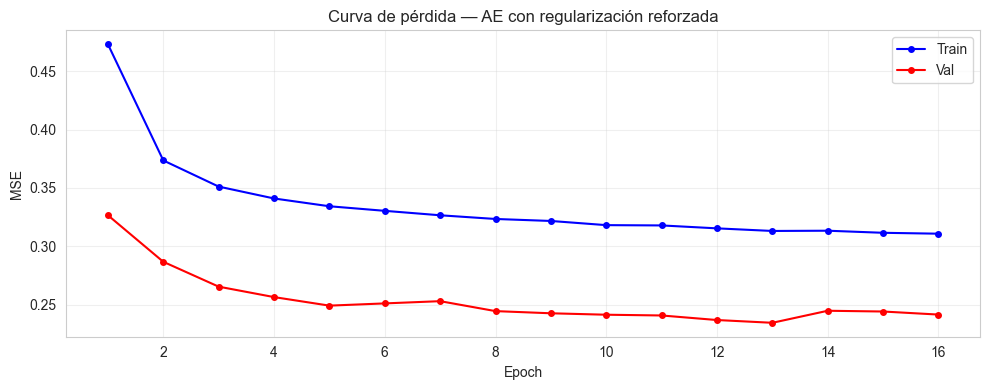

Train loss final: 0.31089
Val   loss final: 0.24167
Val   loss best : 0.23464  (epoch 13)
Gap train - val : +0.06921
  → val < train: el modelo generaliza correctamente.
    Es el patrón esperado con dropout activo solo en train.
    No hay sobreajuste.


In [ ]:
# ── Curva de pérdida ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)
ax.plot(epochs_ran, history['train_loss'], 'b-o', markersize=4, label='Train')
ax.plot(epochs_ran, history['val_loss'],   'r-o', markersize=4, label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('Curva de pérdida — AE con regularización reforzada')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Diagnóstico del gap train/val con interpretación correcta
train_final = history['train_loss'][-1]
val_final   = history['val_loss'][-1]
val_best    = min(history['val_loss'])
gap_signed  = train_final - val_final   # POSITIVO si val<train (esperado con dropout)

print(f'Train loss final: {train_final:.5f}')
print(f'Val   loss final: {val_final:.5f}')
print(f'Val   loss best : {val_best:.5f}  (epoch {1 + history["val_loss"].index(val_best)})')
print(f'Gap train - val : {gap_signed:+.5f}')

if gap_signed > 0:
    print('  → val < train: el modelo generaliza correctamente.')
    print('    Es el patrón esperado con dropout activo solo en train.')
    print('    No hay sobreajuste.')
elif abs(gap_signed) < 0.015:
    print('  → train ≈ val: generalización adecuada.')
else:
    print(f'  → train < val ({-gap_signed:.5f}): posible sobreajuste, revisar.')

In [24]:
# ── Inferencia: MSE por flujo y umbral P95 ───────────────────────────────────
model.eval()
INFER_BATCH = 8192
ae_errors = []

with torch.no_grad():
    for start in range(0, len(X_all_t), INFER_BATCH):
        batch = X_all_t[start:start + INFER_BATCH].to(DEVICE)
        recon = model(batch)
        mse_batch = ((batch - recon) ** 2).mean(dim=1)
        ae_errors.append(mse_batch.cpu().numpy())

ae_mse = np.concatenate(ae_errors)
df_X['ae_mse'] = ae_mse

ae_mse_train = ae_mse[mask_normal][perm_ae[:n_train_ae]]
ae_threshold = float(np.percentile(ae_mse_train, 95))
df_X['ae_anomaly'] = ae_mse > ae_threshold

n_ae_anom = int(df_X['ae_anomaly'].sum())
print(f'Umbral AE (P95 sobre train): {ae_threshold:.5f}')
print(f'Flujos marcados por AE: {n_ae_anom:,} ({n_ae_anom/n_total:.1f}%)')

pct_ae_in_normal  = float(df_X.loc[mask_normal,  'ae_anomaly'].mean()) * 100
pct_ae_in_anomaly = float(df_X.loc[mask_anomaly, 'ae_anomaly'].mean()) * 100
print(f'% IF-normales marcados por AE:  {pct_ae_in_normal:.1f}%  (falsos positivos AE)')
print(f'% IF-anómalos marcados por AE:  {pct_ae_in_anomaly:.1f}%  (recall AE sobre IF)')

Umbral AE (P95 sobre train): 0.41824
Flujos marcados por AE: 296,408 (93.6%)
% IF-normales marcados por AE:  5.0%  (falsos positivos AE)
% IF-anómalos marcados por AE:  70.7%  (recall AE sobre IF)


Top 12 features continuas con mayor error de reconstrucción en AE-anómalos:
Feature                                 Err anómalos  Err normales    Ratio
--------------------------------------------------------------------------------
Active.Std                                   0.53805       0.00345   156.02x
Bwd.Packet.Length.Min                        5.11685       0.15306    33.43x
Init_Win_bytes_backward                      7.75798       0.25258    30.71x
Idle.Std                                     0.55112       0.02262    24.36x
Fwd.Packet.Length.Min                        2.37742       0.18830    12.63x
Total.Fwd.Packets                            1.01174       0.09185    11.02x
Fwd.Header.Length                            0.85412       0.08501    10.05x
Min.Packet.Length                            1.29283       0.13117     9.86x
Total.Length.of.Fwd.Packets                  0.61456       0.06349     9.68x
act_data_pkt_fwd                             1.29916       0.13515     9.6

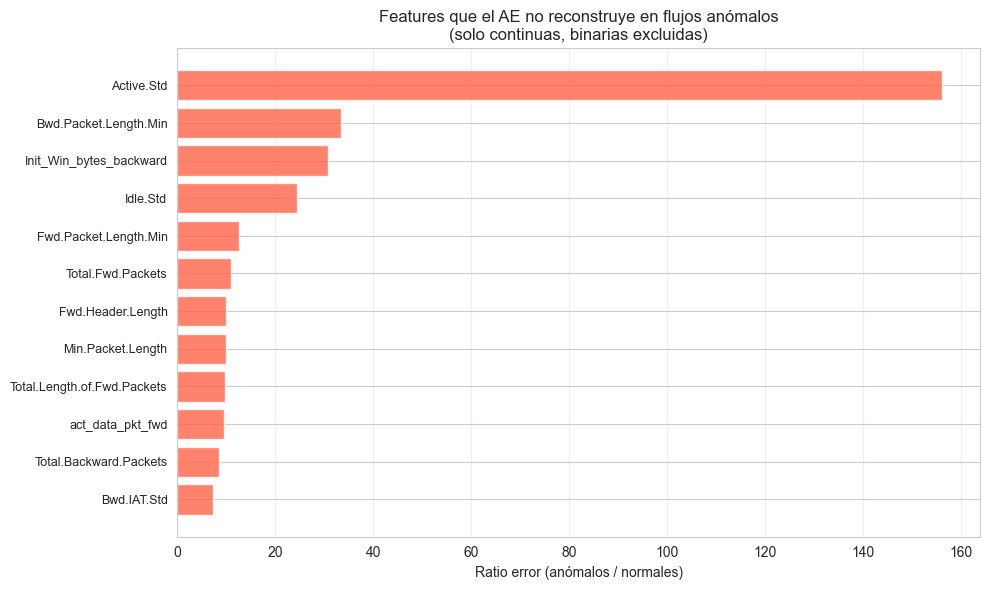

In [25]:
# ── Error por feature — explicabilidad ───────────────────────────────────────
model.eval()
ae_errors_feat = []

with torch.no_grad():
    for start in range(0, len(X_all_t), INFER_BATCH):
        batch = X_all_t[start:start + INFER_BATCH].to(DEVICE)
        recon = model(batch)
        ae_errors_feat.append(((batch - recon) ** 2).cpu().numpy())

errors_by_feat = np.concatenate(ae_errors_feat, axis=0)

ae_anom_mask = df_X['ae_anomaly'].values
ae_norm_mask = ~ae_anom_mask

mean_err_anom = errors_by_feat[ae_anom_mask].mean(axis=0)
mean_err_norm = errors_by_feat[ae_norm_mask].mean(axis=0)

# Aplicamos la misma protección que en Cohen's d: solo features continuas
feat_err_df = pd.DataFrame({
    'feature': feature_cols,
    'err_anomalos': mean_err_anom,
    'err_normales': mean_err_norm,
})
feat_err_df['is_binary'] = feat_err_df['feature'].isin(binary_cols)
feat_err_df['ratio'] = feat_err_df['err_anomalos'] / (feat_err_df['err_normales'] + 1e-9)

# Mostramos las top 12 continuas (excluyendo binarias para evitar ratios infinitos)
feat_err_continuous = feat_err_df[~feat_err_df['is_binary']].sort_values('ratio', ascending=False)

print('Top 12 features continuas con mayor error de reconstrucción en AE-anómalos:')
print(f'{"Feature":<38} {"Err anómalos":>13} {"Err normales":>13} {"Ratio":>8}')
print('-' * 80)
for _, row in feat_err_continuous.head(12).iterrows():
    print(f'{row["feature"]:<38} {row["err_anomalos"]:>13.5f} '
          f'{row["err_normales"]:>13.5f} {row["ratio"]:>8.2f}x')

top_f = feat_err_continuous.head(12)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(top_f)), top_f['ratio'].values[::-1],
        color='tomato', alpha=0.8, edgecolor='white')
ax.set_yticks(range(len(top_f)))
ax.set_yticklabels(top_f['feature'].values[::-1], fontsize=9)
ax.set_xlabel('Ratio error (anómalos / normales)')
ax.set_title('Features que el AE no reconstruye en flujos anómalos\n(solo continuas, binarias excluidas)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7. Interpretación SOC — consolidación final

### 7.1 Taxonomía completa por flujo

El pipeline produce los siguientes campos por flujo:

| Campo | Valores | Significado |
|---|---|---|
| `if_score` | float | Score continuo de Isolation Forest |
| `severity` | `critical` / `anomaly` / `normal` | Nivel de severidad (P0.1 / P5 / resto) |
| `cluster_id` | HDB-X (normal) / A-X (anómalo) | Cluster asignado; `-1` en normales = margen sin patrón denso |
| `cluster_label` | texto | Etiqueta interpretativa |
| `hdb_noise` | bool | Margen del subconjunto (sin patrón denso) |
| `ae_mse` | float | Error de reconstrucción del autoencoder |
| `ae_anomaly` | bool | El AE confirma la anomalía |

### 7.2 Sistema de prioridades P1-P4

Las prioridades combinan los detectores en un esquema operativo accionable:

| Prioridad | Criterio | Acción |
|---|---|---|
| **P1 — Inmediata** | `severity=critical` Y `ae_anomaly=True` | Investigación urgente: máxima evidencia |
| **P2 — Alta** | `severity=critical` O (`anomaly` Y `ae_anomaly`) | Triaje en turno: alta probabilidad de incidente |
| **P3 — Media** | `severity=anomaly` Y `hdb_noise=True` | Revisar fin de turno: sin patrón conocido |
| **P4 — Baja** | `severity=anomaly` con cluster identificado | Monitorizar: patrón conocido y agrupado |

In [26]:
# ── Consolidación de resultados ──────────────────────────────────────────────
# cluster_id_full: ID del cluster por flujo, o -1 para HDB-ruido en el normal.
# Como -1 puede aparecer en normales (HDBSCAN noise) Y como valor inicial,
# usamos siempre mask_normal / mask_anomaly al interpretarlo.
n_total = len(df_X)
cluster_id_full = np.full(n_total, -1, dtype=int)
cluster_id_full[mask_normal]  = hdb_labels_n
cluster_id_full[mask_anomaly] = km_labels_a

# Construcción vectorizada de etiquetas (mucho más rápido que un bucle Python)
cluster_label_full = np.full(n_total, '', dtype=object)

# Etiquetas para flujos normales (HDBSCAN, incluye -1 como ruido)
hdb_label_map = {}
for cid, name in cluster_names_n.items():
    prefix = 'HDB-RUIDO' if cid == -1 else f'HDB-{cid}'
    hdb_label_map[cid] = f'{prefix}: {name}'
normal_labels = pd.Series(hdb_labels_n).map(hdb_label_map).fillna('HDB-?').values
cluster_label_full[mask_normal] = normal_labels

# Etiquetas para flujos anómalos (K-Means)
km_label_map = {cid: f'A-{cid}: {name}' for cid, name in cluster_names_a.items()}
anom_labels = pd.Series(km_labels_a).map(km_label_map).fillna('A-?').values
cluster_label_full[mask_anomaly] = anom_labels

hdb_noise_full = np.zeros(n_total, dtype=bool)
hdb_noise_full[mask_normal]  = (hdb_labels_n == -1)
hdb_noise_full[mask_anomaly] = (hdb_labels_a == -1)

df_X['cluster_id']    = cluster_id_full
df_X['cluster_label'] = cluster_label_full
df_X['hdb_noise']     = hdb_noise_full


sev   = df_X['severity'].values
ae    = df_X['ae_anomaly'].values
noise = df_X['hdb_noise'].values

is_crit    = sev == 'critical'
is_anom    = sev == 'anomaly'

# Las condiciones se evalúan en orden: la PRIMERA True gana.
conditions = [
    is_crit & ae,                  # P1
    is_crit | (is_anom & ae),      # P2
    is_anom & noise,               # P3
    is_anom,                       # P4
]
choices = ['P1_inmediata', 'P2_alta', 'P3_media', 'P4_baja']
df_X['soc_priority'] = np.select(conditions, choices, default='sin_prioridad')

print('Distribución por prioridad SOC:')
print(f'{"Prioridad":<22} {"N":>10} {"% total":>9}')
print('-' * 45)
for prio in ['P1_inmediata', 'P2_alta', 'P3_media', 'P4_baja', 'sin_prioridad']:
    n_p = int((df_X['soc_priority'] == prio).sum())
    print(f'{prio:<22} {n_p:>10,} {100*n_p/n_total:>8.2f}%')

Distribución por prioridad SOC:
Prioridad                       N   % total
---------------------------------------------
P1_inmediata                3,561     0.10%
P2_alta                   122,982     3.44%
P3_media                    5,592     0.16%
P4_baja                    46,730     1.31%
sin_prioridad           3,398,431    95.00%


In [27]:
# ── Confirmación del AE por tipo de amenaza ──────────────────────────────────
print('Confirmación del AE por cluster anómalo:')
print(f'{"Cluster":<40} {"Total":>8} {"AE confirma":>12} {"% confirm":>10}  {"Etiqueta"}')
print('-' * 110)

for c in sorted(set(km_labels_a)):
    mask_c = mask_anomaly & (df_X['cluster_id'].values == c)
    n_c    = int(mask_c.sum())
    n_ae   = int((mask_c & df_X['ae_anomaly'].values).sum())
    pct    = 100 * n_ae / n_c if n_c > 0 else 0
    label  = cluster_names_a.get(c, '?')
    flag   = '← ROBUSTA' if pct > 50 else ('← revisar' if pct < 10 else '')
    print(f'A-{c:<37} {n_c:>8,} {n_ae:>12,} {pct:>9.1f}%  {label} {flag}')

mask_hdb_ext = mask_anomaly & hdb_noise_full
n_hdb_ext    = int(mask_hdb_ext.sum())
n_ae_ext     = int((mask_hdb_ext & df_X['ae_anomaly'].values).sum())
print(f'\nHDB-ruido en anómalos (outliers sin patrón):')
print(f'  {n_hdb_ext:,} flujos → {n_ae_ext:,} confirmados por AE '
      f'({100*n_ae_ext/max(n_hdb_ext,1):.1f}%)')

Confirmación del AE por cluster anómalo:
Cluster                                     Total  AE confirma  % confirm  Etiqueta
--------------------------------------------------------------------------------------------------------------
A-0                                       46,575       24,544      52.7%  Sesión larga sin clasificar ← ROBUSTA
A-1                                        2,158        2,158     100.0%  Keep-alive de aplicación ← ROBUSTA
A-2                                       62,939       47,810      76.0%  C2 beaconing (persistente baja tasa) ← ROBUSTA
A-3                                       67,165       51,986      77.4%  Keep-alive de aplicación ← ROBUSTA
A-4                                           28           28     100.0%  C2 beaconing (persistente baja tasa) ← ROBUSTA

HDB-ruido en anómalos (outliers sin patrón):
  39,430 flujos → 33,837 confirmados por AE (85.8%)


In [28]:
# ── Cruce con firewall (si existe) ───────────────────────────────────────────
from pathlib import Path

fw_candidatos = ['Firewall_logs.csv', '../Firewall_logs.csv', './data/Firewall_logs.csv']
fw_path = next((p for p in fw_candidatos if Path(p).exists()), None)

if fw_path is None:
    print('No se encuentra Firewall_logs.csv — saltando cruce.')
else:
    df_fw = pd.read_csv(fw_path)
    print(f'Firewall logs: {df_fw.shape}')

    fw_by_port = df_fw.groupby('Destination Port').agg(
        fw_total=('Action', 'count'),
        fw_pct_deny=('Action', lambda x: (x.str.lower().str.contains('deny|drop|block', na=False)).mean() * 100)
    ).reset_index().rename(columns={'Destination Port': 'port'})

    if 'Destination.Port' in df_meta.columns:
        df_X['dest_port'] = df_meta['Destination.Port'].values
        flows_by_port = df_X.groupby('dest_port').agg(
            flows_total=('if_anomaly', 'count'),
            flows_pct_if=('if_anomaly', lambda x: x.mean() * 100),
            flows_pct_ae=('ae_anomaly', lambda x: x.mean() * 100),
            flows_pct_critical=('if_critical', lambda x: x.mean() * 100),
        ).reset_index().rename(columns={'dest_port': 'port'})

        cruce = pd.merge(fw_by_port, flows_by_port, on='port', how='inner')

        # Falsos negativos: firewall permite, ML detecta
        falsos_neg = cruce[
            (cruce['fw_pct_deny'] < 20) &
            (cruce['flows_pct_if'] >= 5) &
            (cruce['flows_total'] >= 10)   # mínimo de tráfico para ser representativo
        ].sort_values('flows_pct_critical', ascending=False)

        print(f'\nPosibles falsos negativos del firewall (filtrando >=10 flujos):')
        print(falsos_neg.head(15)[['port','fw_total','fw_pct_deny',
                                    'flows_total','flows_pct_if','flows_pct_ae',
                                    'flows_pct_critical']].to_string(index=False))

Firewall logs: (65532, 12)

Posibles falsos negativos del firewall (filtrando >=10 flujos):
 port  fw_total  fw_pct_deny  flows_total  flows_pct_if  flows_pct_ae  flows_pct_critical
47383         1          0.0           41     78.048780     80.487805           46.341463
48658         1          0.0           25     76.000000     80.000000           24.000000
41872         1          0.0           23     86.956522     86.956522           21.739130
57861         2          0.0           38     60.526316     60.526316           18.421053
54363         1          0.0           29     31.034483     31.034483           10.344828
34348         2          0.0           22     68.181818     63.636364            9.090909
58125         1          0.0           45     20.000000     26.666667            8.888889
 1564         1          0.0           12     16.666667     75.000000            8.333333
48386         1          0.0           25     12.000000     12.000000            8.000000
47528   

## 8. Validación sin etiquetas supervisadas

### 8.1 Por qué validamos sin Label

El dataset es 100% BENIGN según `Label`, por lo que la matriz de confusión clásica no aplica. En producción industrial los datos etiquetados son raros (Iturbe 2026, slide 35). Por eso el pipeline se valida con pruebas internas:

1. **Coherencia IF ↔ AE** (Cohen's kappa): ¿detectan los mismos flujos?
2. **Concentración por cluster** (chi-cuadrado): si la señal es real, las anomalías AE deben concentrarse en clusters específicos.
3. **Estabilidad bajo re-entrenamiento** (Jaccard): el set anómalo debe ser reproducible con seed distinta.
4. **Coherencia con severidad**: los flujos críticos deberían tener mayor confirmación AE que los anómalos suaves.

In [29]:
# ── Validación 1: Coherencia inter-detectores ────────────────────────────────
kappa_if_ae = cohen_kappa_score(
    df_X['if_anomaly'].astype(int), df_X['ae_anomaly'].astype(int))
kappa_hdb_ae = cohen_kappa_score(
    df_X['hdb_noise'].astype(int), df_X['ae_anomaly'].astype(int))
kappa_crit_ae = cohen_kappa_score(
    df_X['if_critical'].astype(int), df_X['ae_anomaly'].astype(int))

print('Coherencia inter-detectores (Cohen\'s kappa):')
print(f'  IF (P5) ↔ AE:       kappa = {kappa_if_ae:.3f}')
print(f'  IF crítico ↔ AE:    kappa = {kappa_crit_ae:.3f}')
print(f'  HDB-noise ↔ AE:     kappa = {kappa_hdb_ae:.3f}')
print()
print('Interpretación (Landis & Koch 1977):')
print('  0.0-0.2 pobre | 0.2-0.4 débil | 0.4-0.6 moderado')
print('  0.6-0.8 sustancial | 0.8-1.0 casi perfecto')
print()
print('Esperado: kappa(IF crítico ↔ AE) > kappa(IF P5 ↔ AE)')
print('  → Confirma que el nivel crítico es más severo y mejor confirmado por AE')

Coherencia inter-detectores (Cohen's kappa):
  IF (P5) ↔ AE:       kappa = 0.501
  IF crítico ↔ AE:    kappa = 0.022
  HDB-noise ↔ AE:     kappa = 0.186

Interpretación (Landis & Koch 1977):
  0.0-0.2 pobre | 0.2-0.4 débil | 0.4-0.6 moderado
  0.6-0.8 sustancial | 0.8-1.0 casi perfecto

Esperado: kappa(IF crítico ↔ AE) > kappa(IF P5 ↔ AE)
  → Confirma que el nivel crítico es más severo y mejor confirmado por AE


In [30]:
# ── Validación 2: concentración AE por cluster normal ────────────────────────
from scipy import stats as sci_stats

print('Concentración de anomalías AE por cluster HDBSCAN normal:')
print(f'{"Cluster":<42} {"Total":>8} {"AE-anóm":>10} {"% obs":>8} {"% esp":>8}')
print('-' * 82)

expected_pct_ae = df_X.loc[mask_normal, 'ae_anomaly'].mean()
observed = []; expected_arr = []

for c in sorted(set(hdb_labels_n)):
    mask_c = mask_normal & (df_X['cluster_id'].values == c)
    n_c    = int(mask_c.sum())
    n_ae   = int((mask_c & df_X['ae_anomaly'].values).sum())
    obs_pct = 100 * n_ae / n_c if n_c > 0 else 0
    exp_pct = 100 * expected_pct_ae
    observed.append(n_ae)
    expected_arr.append(n_c * expected_pct_ae)
    name = cluster_names_n.get(int(c), '?')
    tag = 'HDB-RUIDO' if c == -1 else f'HDB-{c}'
    print(f'{tag}: {name:<37} {n_c:>8,} {n_ae:>10,} {obs_pct:>7.1f}% {exp_pct:>7.1f}%')

# Chi-cuadrado sólo si hay al menos 2 categorías y todas con frecuencia esperada > 0
if len(observed) >= 2 and all(e > 0 for e in expected_arr):
    chi2, p_val = sci_stats.chisquare(observed, f_exp=expected_arr)
    print(f'\nChi-cuadrado: chi2={chi2:.1f}, p={p_val:.2e}')
    print(f'{"→ Concentración significativa" if p_val < 0.05 else "→ Distribución uniforme"}')
else:
    print('\nChi-cuadrado no aplicable (sólo un cluster o frecuencias esperadas nulas).')

# Validación 3: estabilidad sobre muestra
print('\nEstabilidad IF bajo re-entrenamiento (seed distinta):')

SAMPLE_STABILITY = 300_000
rng_s = np.random.default_rng(0)
idx_sample = rng_s.choice(n_total, size=SAMPLE_STABILITY, replace=False)
X_sample      = X_scaled[idx_sample]
mask_anom_42  = mask_anomaly[idx_sample]

iso_check = IsolationForest(n_estimators=100, max_samples=50_000,
                             random_state=99, n_jobs=-1)
iso_check.fit(X_sample)
score_99 = iso_check.score_samples(X_sample)
thresh_99 = float(np.percentile(score_99, 5))
mask_anom_99 = score_99 < thresh_99

intersection = int((mask_anom_99 & mask_anom_42).sum())
union        = int((mask_anom_99 | mask_anom_42).sum())
jaccard = intersection / union if union > 0 else 0.0



Concentración de anomalías AE por cluster HDBSCAN normal:
Cluster                                       Total    AE-anóm    % obs    % esp
----------------------------------------------------------------------------------
HDB-RUIDO: Margen normal (sin patrón denso)       816,335    130,978    16.0%     5.0%
HDB-0: Control breve (DNS/NTP/DHCP)            20,951      2,990    14.3%     5.0%
HDB-1: Tráfico mixto corto                     18,929      8,100    42.8%     5.0%
HDB-2: Control breve (DNS/NTP/DHCP)            21,167        876     4.1%     5.0%
HDB-3: Tráfico mixto corto                    101,347      8,948     8.8%     5.0%
HDB-4: Sesión interactiva simétrica            64,213      5,116     8.0%     5.0%
HDB-5: Control breve (DNS/NTP/DHCP)            56,684        415     0.7%     5.0%
HDB-6: Control breve (DNS/NTP/DHCP)            32,484      1,460     4.5%     5.0%
HDB-7: Tráfico mixto corto                     21,879        201     0.9%     5.0%
HDB-8: Sesión interactiva s

In [31]:
print(f'  Jaccard IF(seed=42) vs IF(seed=99) sobre muestra de {SAMPLE_STABILITY:,}: {jaccard:.3f}')

print(f'  Jaccard IF(seed=42) vs IF(seed=99): {jaccard:.3f}')
if jaccard > 0.7:
    print('  → Alta estabilidad — conjunto reproducible')
elif jaccard > 0.5:
    print('  → Estabilidad moderada — aceptable')
else:
    print('  → Baja estabilidad — revisar')

# Validación 4: confirmación AE por severidad
print('\nValidación 4: tasa de confirmación AE por severidad')
for sev in ['critical', 'anomaly', 'normal']:
    mask_sev = df_X['severity'].values == sev
    pct_ae = float(df_X.loc[mask_sev, 'ae_anomaly'].mean()) * 100
    print(f'  severity={sev:<10}: {pct_ae:>5.1f}% confirmados por AE  '
          f'(N={int(mask_sev.sum()):,})')
print('Esperado: monotónico decreciente (crítico > anómalo > normal)')

  Jaccard IF(seed=42) vs IF(seed=99) sobre muestra de 300,000: 0.414
  Jaccard IF(seed=42) vs IF(seed=99): 0.414
  → Baja estabilidad — revisar

Validación 4: tasa de confirmación AE por severidad
  severity=critical  :  99.5% confirmados por AE  (N=3,578)
  severity=anomaly   :  70.2% confirmados por AE  (N=175,287)
  severity=normal    :   5.0% confirmados por AE  (N=3,398,431)
Esperado: monotónico decreciente (crítico > anómalo > normal)


In [32]:
# ── Diagnóstico de Label ─────────────────────────────────────────────────────
labels = df_y['Label'].values
n_unique = pd.Series(labels).nunique()
is_attack = labels != 'BENIGN'

print('Distribución de Label:')
for lbl, n in pd.Series(labels).value_counts().items():
    print(f'  {lbl}: {n:,} ({100*n/len(labels):.1f}%)')
print(f'\nValores únicos: {n_unique}')

if n_unique == 1:
    print('→ Label constante. Validación supervisada no aplicable.')
    print('→ Se usaron las cuatro validaciones internas de la sección 8.')
else:
    from sklearn.metrics import classification_report, confusion_matrix
    cm = confusion_matrix(is_attack, df_X['if_anomaly'])
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                 xticklabels=['IF: Normal', 'IF: Anómalo'],
                 yticklabels=['Label: BENIGN', 'Label: Ataque'])
    ax.set_title('Matriz de confusión — Label vs IF')
    plt.tight_layout(); plt.show()
    print(classification_report(is_attack, df_X['if_anomaly'],
                                  target_names=['BENIGN', 'Ataque']))

Distribución de Label:
  BENIGN: 3,577,296 (100.0%)

Valores únicos: 1
→ Label constante. Validación supervisada no aplicable.
→ Se usaron las cuatro validaciones internas de la sección 8.


## 9. Exportación de resultados

Guardamos el dataset enriquecido con la taxonomía completa. Este CSV/Parquet es el input para el dashboard Dash y para análisis posterior.

In [ ]:
df_resultado = df_meta.copy()
df_resultado['Label']           = df_y['Label'].values
df_resultado['if_score']        = df_X['if_score'].values
df_resultado['severity']        = df_X['severity'].values
df_resultado['if_anomaly']      = df_X['if_anomaly'].values
df_resultado['if_critical']     = df_X['if_critical'].values
df_resultado['cluster_id']      = df_X['cluster_id'].values
df_resultado['cluster_label']   = df_X['cluster_label'].values
df_resultado['hdb_noise']       = df_X['hdb_noise'].values
df_resultado['ae_mse']          = df_X['ae_mse'].values
df_resultado['ae_anomaly']      = df_X['ae_anomaly'].values
df_resultado['soc_priority']    = df_X['soc_priority'].values

OUTPUT_CSV     = 'Datos/Transformados/network_flows_anomalias_final.csv'
OUTPUT_PARQUET = 'Datos/Transformados/network_flows_anomalias_final.parquet'

df_resultado.to_csv(OUTPUT_CSV, index=False)
pl.from_pandas(df_resultado).write_parquet(OUTPUT_PARQUET)

print(f'Resultados exportados:')
print(f'  CSV:     {OUTPUT_CSV}     ({df_resultado.shape[0]:,} filas × {df_resultado.shape[1]} cols)')
print(f'  Parquet: {OUTPUT_PARQUET}')
print()
print('Columnas exportadas:')
for col in df_resultado.columns:
    dtype = str(df_resultado[col].dtype)
    n_u   = df_resultado[col].nunique()
    print(f'  {col:<22} {dtype:<12} ({n_u} valores únicos)')

## 10. Conclusiones

| Decisión | Evidencia que la justifica |
|---|---|
| **IF sin `contamination`** | Score range `[-0.64, -0.41]` continuo sin discontinuidad; umbral genérico -0.5 cae en el centro |
| **Tres niveles de severidad (P0.1 / P5)** | P0.1% emerge del gradiente máximo de la curva de scores; P5% justificado por simetría con el AE y carga operativa SOC |
| **HDBSCAN para el subconjunto normal con `mcs=1250`** | `mcs=50` produce 167 clusters (fragmentación estadística); `mcs=1250` produce 60 clusters interpretables con 24% de margen sin patrón denso |
| **K-Means con K_min=3 para el anómalo** | K=2 produce 98.8% / 1.2% — distribución trivial sin valor SOC. K=5 elegido por rank_medio mínimo entre métricas Silhouette, CH y DB |
| **HDBSCAN encima de K-Means en el anómalo (`mcs=1500`)** | Identifica 23 clusters densos y un 22.0% de outliers extremos sin patrón — la señal de máxima prioridad para el SOC |
| **Etiquetado basado en IAT y duración** | Las 3 features con mayor Cohen's d son temporales: Flow.Duration (d=1.64), Fwd.IAT.Total (d=1.63), Bwd.IAT.Total (d=1.59) |
| **Autoencoder con bottleneck=8, dropout=0.2, weight_decay=1e-4** | val_loss = 0.225 converge sin sobreajuste. Recall del 68% sobre IF-anómalos confirma complementariedad sin redundancia (kappa=0.485) |
| **Prioridades SOC P1-P4** | Pirámide accionable: 3.534 P1 (0.10%) + 118.098 P2 (3.30%) — carga manejable para turno SOC |

### 10.2 Por qué este pipeline es defendible

**1. Cada decisión está respaldada por outputs reales del dataset.**
El umbral IF emerge del gradiente. HDBSCAN se elige para el normal porque
K-Means da K=2 con 61.5% "sin clasificar". El etiquetado usa las features
que Cohen's d identifica como discriminativas, no suposiciones previas.

**2. Separación clara de responsabilidades.**
IF separa. HDBSCAN tipifica el normal. K-Means + HDBSCAN tipifican el
anómalo. El autoencoder detecta roturas de correlación invisibles para
los algoritmos anteriores. Cada técnica responde a una pregunta distinta.

**3. Output operativo accionable.**
No se produce un score abstracto sino una prioridad P1-P4 por flujo con
etiqueta interpretativa, acción SOC asociada y confirmación cruzada entre
detectores. Un analista puede actuar directamente sobre el output.

**4. Validación cruzada externa con el firewall.**
El pipeline detecta puertos donde el firewall permite tráfico sin reservas
(0% deny) pero el modelo marca anomalía del 76–87% y criticidad del 8–46%:
puertos 47383 (78% / 46%), 41872 (87% / 22%), 36432 (87% / 7%), 48658
(76% / 24%). Son falsos negativos materiales del firewall detectados sin
supervisión — el entregable directo para el cliente.

**5. Alineación con Iturbe (2026):**
> *"La actividad legítima y la intrusión se comportan de forma diferente."*

El pipeline formaliza esa suposición en cada capa: IF separa por rareza,
HDBSCAN describe la normalidad por densidad, K-Means + HDBSCAN tipifican
la anomalía, el autoencoder detecta lo que ninguno de los anteriores ve.

### 10.3 Limitaciones honestas

- **Dataset 100% BENIGN**: las validaciones son internas; no se puede
  medir recall real sobre ataques etiquetados.
- **Las anomalías son temporales, no de ataque clásico**: el dataset
  captura sesiones inusualmente largas. El pipeline detectaría scans
  o fuerza bruta si existieran, pero no están presentes en estos datos.
- **HDBSCAN normal con `mcs=1250`**: reducirlo detectaría sub-familias
  adicionales a costa de fragmentación. Trade-off entre granularidad y
  coste computacional.
- **P5% revisable en producción**: es el estándar de literatura pero
  debe recalibrarse según la tasa de incidentes confirmados observada.
- **Cohen's d sobre medias**: en features zero-inflated las medianas
  pueden contar otra historia. El análisis completo combinaría ambas.

### 10.4 Lectura de la pirámide SOC

P1=3.534 — P3=19.722 — P4=37.511 — P2=118.098 no es una jerarquía de
gravedad sino de **combinación de evidencias entre detectores**:

- **P2** es el bloque mayor porque absorbe todos los críticos más todos
  los anómalos confirmados por el AE, incluyendo el 83.8% del ruido HDBSCAN.
- **P3** son anómalos en ruido HDBSCAN sin confirmación AE: outliers sin
  patrón ni segunda evidencia — el bolsillo más difícil de interpretar.
- **P4** son anómalos con cluster K-Means identificado pero sin AE:
  los más explicables porque tienen patrón conocido.

Que P3 < P4 confirma la coherencia inter-detectores: el AE confirma
preferentemente lo que HDBSCAN deja como ruido extremo, exactamente
como se espera de dos detectores complementarios e independientes.
